# Relatório de Avaliação Comparativa de Classificadores

O objetivo desta atividade é realizar uma análise comparativa entre diferentes classificadores de aprendizagem de máquina utilizando a base de dados Adult Income da UCI. A partir da aplicação dos protocolos de avaliação estatística discutidos por J. Demšar, pretende-se desenvolver habilidades críticas na interpretação e análise dos resultados obtidos em métricas de desempenho como acurácia, precisão, recall, F1-score e curva ROC. Além disso, a atividade visa explorar a aplicação de testes estatísticos para identificar diferenças significativas entre os classificadores, promovendo uma compreensão mais aprofundada dos impactos dos parâmetros de configuração no desempenho dos modelos.

## 1. Revisão Teórica

### Funcionamento dos Classificadores

Destacamos as principais características, vantagens e desvantagens de cada modelo utilizados.

#### Multi-Layer Perceptron (MLP)

* **Funcionamento:** Rede neural composta por camadas (entrada, ocultas e saída), onde cada neurônio aplica uma função de ativação (ex.: ReLU, Sigmoid) e ajusta pesos via retropropagação.

* **Vantagens:** 

    * Capaz de capturar relações não lineares complexas, altamente flexível com ajuste de camadas e neurônios, eficaz em grandes datasets.

* **Desvantagens:** 

    * Requer alto poder computacional, propenso ao overfitting se não regularizado, tuning complexo dos hiperparâmetros (ex.: número de camadas, learning rate).

#### Learning Vector Quantization (LVQ)

* **Funcionamento:** Rede neural competitiva que utiliza protótipos representativos para classificar os dados, ajustando-os para melhorar a separação entre classes.

* **Vantagens**: 
    * Interpretação intuitiva dos protótipos, adequado para problemas de classificação, robusto a ruído.

* **Desvantagens:** 
    * Sensível à escolha inicial dos protótipos, pode convergir para mínimos locais, menos eficaz em problemas de alta dimensionalidade.

#### Decision Tree (Árvore de Decisão):

* **Funcionamento:** Cria uma estrutura hierárquica de decisões baseada em perguntas binárias ou múltiplas. Cada nó representa uma decisão baseada em um atributo específico, e os ramos representam os possíveis resultados.

* **Vantagens:**

  * Interpretação intuitiva e visualização fácil.
  * Não requer normalização dos dados.
  * Lida bem com dados categóricos e numéricos.

* **Desvantagens:**

  * Propensa ao overfitting se não podada adequadamente.
  * Sensível a pequenas variações nos dados.
  * Pode gerar árvores muito profundas e complexas.


#### Random Forest (Floresta Aleatória):

* **Funcionamento:** Cria múltiplas árvores de decisão treinadas com subconjuntos aleatórios do dataset (tanto amostras quanto atributos) e utiliza a média ou voto da maioria para definir a predição final.

* **Vantagens:**

  * Reduz overfitting em comparação à árvore de decisão única.
  * Robusta contra ruído e outliers.
  * Lida bem com datasets grandes e complexos.

* **Desvantagens:**

  * Pode ser mais lenta no treinamento e na predição.
  * Menos interpretável do que uma única árvore de decisão.
  * Requer mais memória devido ao armazenamento de múltiplas árvores.


#### Support Vector Machine (SVM):

* **Funcionamento:** Encontra o hiperplano ótimo que maximiza a margem entre as classes, utilizando métodos de kernel para lidar com problemas não linearmente separáveis.

* **Vantagens:**

  * Eficaz em espaços de alta dimensionalidade.
  * Flexível com o uso de diferentes funções kernel (linear, polinomial, radial, etc.).
  * Resistente ao overfitting em conjuntos de dados de pequenas dimensões.

* **Desvantagens:**

  * Custo computacional elevado para datasets grandes.
  * Requer ajuste cuidadoso dos hiperparâmetros (ex.: C e gamma).
  * Menos interpretável do que outros métodos (como árvores de decisão).


#### K-Nearest Neighbors (KNN)

* **Funcionamento:** Armazena todo o conjunto de treinamento e classifica um novo ponto com base na maioria dos vizinhos mais próximos (k). A proximidade é calculada por métricas como a Euclidiana, Manhattan, etc.

* **Vantagens:**

  * Simplicidade de implementação e compreensão.
  * Eficaz em datasets pequenos e bem distribuídos.
  * Não faz suposições sobre a distribuição dos dados.

* **Desvantagens:**

  * Custo computacional elevado em datasets grandes.
  * Sensível a outliers e ruído.
  * Necessita de escolha adequada do valor de **k**.


## Exploração , Análise e Tratamento dos Dados: DataSet -> Adult Income

### 1.- **Introdução e Objetivos** ###

 - O objetivo é preparar a Base de Dados Adult Income antes de ser inserida nos algoritmos de classificação. Ao Final destes script, será exportado o aqruivo 'adult_tratado.csv' para que posteriormente seja utilizado nos algoritmos de classificação


O dataset "adult Income" é um conjunto de dados amplamente utilizado para tarefas de classificação em aprendizado de máquina. O objetivo principal é prever se a renda de um indivíduo excede US$ 50K por ano com base em diversos atributos demográficos e socioeconômicos. 


Visão Geral do Dataset:
 - Objetivo: Prever se a renda de um indivíduo é ">50K" ou "<=50K" por ano.
 - Número de Atributos: 14 atributos (além da variável alvo 'income').
 - Tipos de Atributos: Categóricos e Contínuos.
 - Valores Ausentes: O dataset original possui valores ausentes representados por "?".


### 2.- **Exploração dos Dados** ###

####   2.1-- *Importando as Bibliotecas para exploração e análise dos dados* ####

In [1]:
# Importando as Bibliotecas para exploração e análise dos dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

#### 2.2-- *Análise inicial do DataFrame* ####

In [2]:
# Carregamento da base de dados Adult em um DataFrame
dataset = pd.read_csv("adult.data", header= None, na_values="?", skipinitialspace=True)
dataset.head() # Como pode Ser abservado são 15 colunas. 14 colunas de atributos (previsoras) e a coluna Alvo (Target)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
# Numeros de Linhas e Colunas (Dataset -> Original)
dataset.shape

(32561, 15)

In [4]:
# Adicionar nomes das colunas (de acordo com a base oficial)
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
           'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
           'hours-per-week', 'native-country', 'income']
dataset.columns = columns # Nomeando as colunas conforme lista Columns
dataset.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
dataset.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

### 3.- **Valores Faltantes** ###

In [6]:
dataset.isnull().sum() # Valores Faltantes

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [7]:
print('(Linhas x Colunas):')
print("Antes de Remover as linhas com dados faltantes (simbolo -> ?):",dataset.shape)
# Remover linhas com valores faltantes
dataset.dropna(inplace=True)

print('(Linhas x Colunas):')
print("Após Remover as linhas com dados faltantes (simbolo -> ?):",dataset.shape)
dataset.head()

(Linhas x Colunas):
Antes de Remover as linhas com dados faltantes (simbolo -> ?): (32561, 15)
(Linhas x Colunas):
Após Remover as linhas com dados faltantes (simbolo -> ?): (30162, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [8]:
# RELAÇÃO DA QUANTIDADE
dataset.isnull().sum() # Valores Faltantes

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

### 4.- **Análise das Variáveis** ###

#### --   *Resumo do Atributos (Features)* ####

1. age: Idade do indivíduo (contínuo).
2. workclass: Classe de trabalhador (categórico): Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.
3. fnlwgt: Peso final, representando o número de indivíduos que as autoridades do censo acreditam que essa entrada representa (contínuo).
4. education: Nível de escolaridade do indivíduo (categórico): Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters,  1st-4th, 10th, Doctorate, 5th-6th, Preschool.
5. education-num: Número de anos de educação alcançados (contínuo).
6. marital-status: Estado civil do indivíduo (categórico): Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.
7. occupation: Ocupação do indivíduo (categórico): Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.
8. relationship: Relação familiar do indivíduo (categórico): Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.
9. race: Raça do indivíduo (categórico): White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.
10. sex: Sexo do indivíduo (categórico): Female, Male.
11. capital-gain: Ganho de capital (contínuo).
12. capital-loss: Perda de capital (contínuo).
13. hours-per-week: Número de horas trabalhadas por semana (contínuo).
14. native-country: País de origem do indivíduo (categórico): United-States, Cuba, Jamaica, Germany, England, Canada, India, Japan, Greece, South, China, Scotland, Italy, Thailand, Hong-Kong, Philippines, Iran, Vietnam, Mexico, Puerto-Rico, Poland, Honduras, El-Salvador, Yugoslavia, Outlying-US(Guam-USVI-etc), Peru, Guatemala, Dominican-Republic, Ireland, Hungary, Columbia, Holand-Netherlands.
15. income: Variável alvo (categórico): >50K, <=50K.

#### 4.1- Age : Idade do indivíduo ####


##### 4.1.1- Dados e Estatisticas #####

Representa a idade do indivíduo e é uma variável numérica contínua.
*Importância do atributo age*
- Pode influenciar a renda: Pessoas mais velhas tendem a ter mais experiência profissional, o que pode impactar seus ganhos.
- Relevante para modelos de machine learning: Pode ser um fator preditivo importante para determinar se um indivíduo ganha mais ou menos de 50K por ano.
- Pode estar correlacionado com outras variáveis: Como ocupação, nível educacional e horas trabalhadas por semana.


In [9]:
dataset.age.value_counts().sort_index()

age
17    328
18    447
19    594
20    629
21    621
     ... 
84      8
85      3
86      1
88      3
90     35
Name: count, Length: 72, dtype: int64

In [10]:
dataset.age.describe()

count    30162.000000
mean        38.437902
std         13.134665
min         17.000000
25%         28.000000
50%         37.000000
75%         47.000000
max         90.000000
Name: age, dtype: float64

##### 4.1.2- Gráfico #####

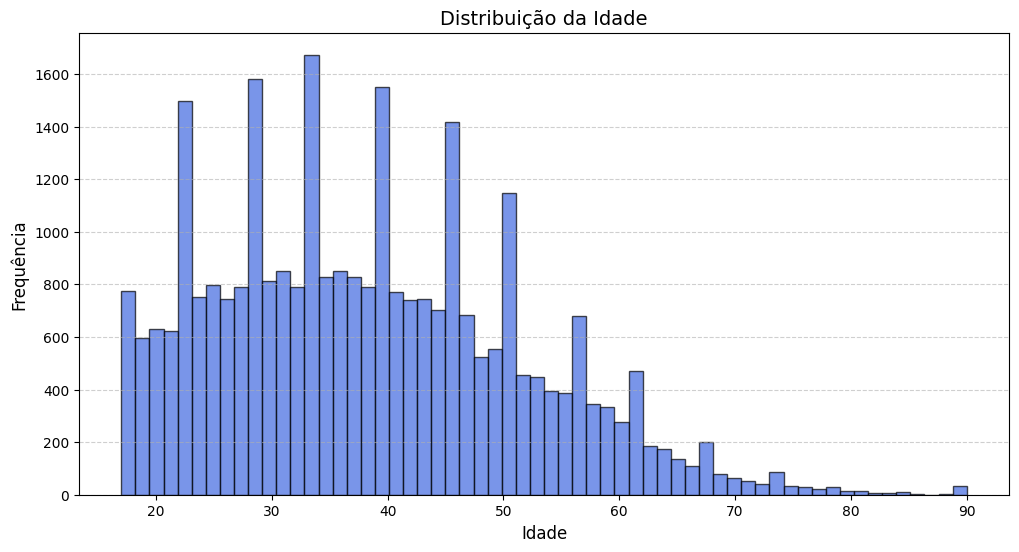

In [11]:
plt.figure(figsize=(12, 6))  
plt.hist(dataset.age, bins=60, color='royalblue', edgecolor='black', alpha=0.7)
plt.title("Distribuição da Idade", fontsize=14)
plt.xlabel("Idade", fontsize=12)
plt.ylabel("Frequência", fontsize=12)

# Ajustando o estilo do grid para melhor visualização
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

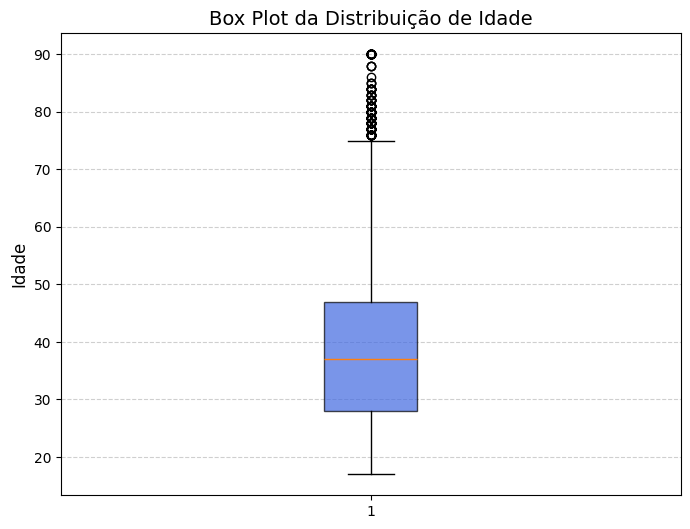

In [12]:
plt.figure(figsize=(8, 6))
plt.boxplot(dataset.age, vert=True, patch_artist=True, boxprops=dict(facecolor='royalblue', alpha=0.7))

# Adicionando título e rótulos
plt.title("Box Plot da Distribuição de Idade", fontsize=14)
plt.ylabel("Idade", fontsize=12)


plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

1. Mediana:
- Está aproximadamente em 37 anos, indicando que metade da população tem menos de 37 anos e a outra metade mais.

2. Quartis:
- Q1 (25%) ≈ 28 anos

- Q3 (75%) ≈ 47 anos

- Isso mostra que 50% dos dados estão entre 28 e 47 anos, o que representa a faixa etária mais comum (distribuição central).

3. Intervalo interquartil (IQR):
- IQR = Q3 - Q1 ≈ 47 - 28 = 19 anos

4. Mínimo e Máximo (sem outliers):
- A idade mínima (sem considerar outliers) parece estar em torno de 17 anos

- A idade máxima (sem considerar outliers) está em torno de 74 anos

5. Outliers (valores fora do padrão):
- Há vários outliers acima de 74 anos, indo até 90 anos

- Esses pontos representam uma parcela pequena, mas importante da população, e podem indicar:

- Pessoas ainda economicamente ativas em idade avançada


#### 4.2- Workclass : Classe de trabalhador, indica o tipo de empregador  ####

##### 4.2.1- Dados #####

In [13]:
cont_worclass = dataset.workclass.value_counts()
cont_worclass.sort_index()


workclass
Federal-gov           943
Local-gov            2067
Private             22286
Self-emp-inc         1074
Self-emp-not-inc     2499
State-gov            1279
Without-pay            14
Name: count, dtype: int64

##### 4.2.2- Gráfico #####

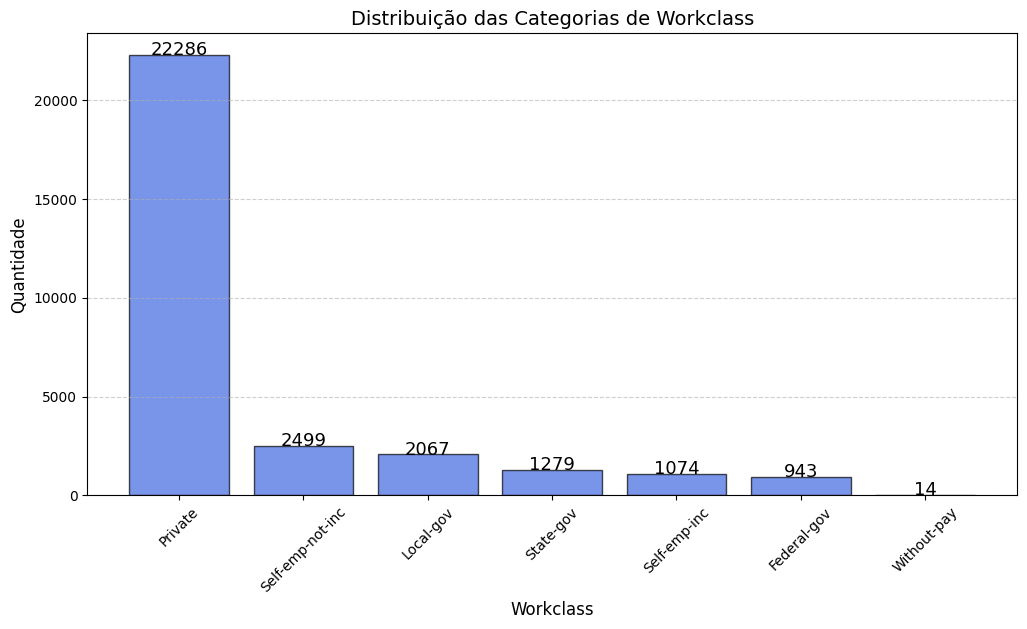

In [14]:
plt.figure(figsize=(12, 6))  # Largura = 20, Altura = 7
plt.bar(cont_worclass.index , cont_worclass.values, color='royalblue', edgecolor='black', alpha=0.7)
plt.title("Distribuição das Categorias de Workclass", fontsize=14)
plt.xlabel("Workclass", fontsize=12)
plt.ylabel("Quantidade", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
for i, valor in enumerate(cont_worclass.values):
    plt.text(i, valor + 0.5, str(valor), ha='center', fontsize=13)
plt.show()

- O setor privado domina amplamente o mercado de trabalho representado neste dataset.

- O número significativo de autônomos (com ou sem empresa) indica um espaço importante para análises sobre empreendedorismo e informalidade.

- Os diferentes níveis do setor público (federal, estadual e local) mostram que o dataset abrange uma diversidade razoável de tipos de emprego governamental.

- As categorias com pouca representação (como without-pay) devem ser tratadas com cuidado na modelagem, pois podem introduzir ruído.

#### 4.3- fnlwgt : Peso final, representando o número de indivíduos que essa entrada do censo representa ####

##### 4.3.1- Resumo #####

- O fnlwgt é calculado com base em fatores como idade, sexo, raça e estado de residência.
- Na maioria dos casos, o fnlwgt não é útil para modelos de aprendizado de máquina, pois é um peso estatístico usado para análises demográficas, não uma característica preditiva.
- Em muitos casos, incluir essa variável pode adicionar ruído ao modelo, reduzindo sua capacidade de generalização.

**TESTAR IMPACTO**

- Rodar o modelo com e sem essa variável.
- Comparar métricas de desempenho.
- Avaliar se há ganho ou perda de precisão.


##### 4.3.2- Dados #####

In [15]:
dataset.fnlwgt.value_counts().sort_index()

fnlwgt
13769      1
14878      1
18827      1
19214      1
19302      5
          ..
1226583    1
1268339    1
1366120    1
1455435    1
1484705    1
Name: count, Length: 20263, dtype: int64

In [16]:
dataset.fnlwgt.describe()

count    3.016200e+04
mean     1.897938e+05
std      1.056530e+05
min      1.376900e+04
25%      1.176272e+05
50%      1.784250e+05
75%      2.376285e+05
max      1.484705e+06
Name: fnlwgt, dtype: float64

##### 4.3.3- Gráfico #####

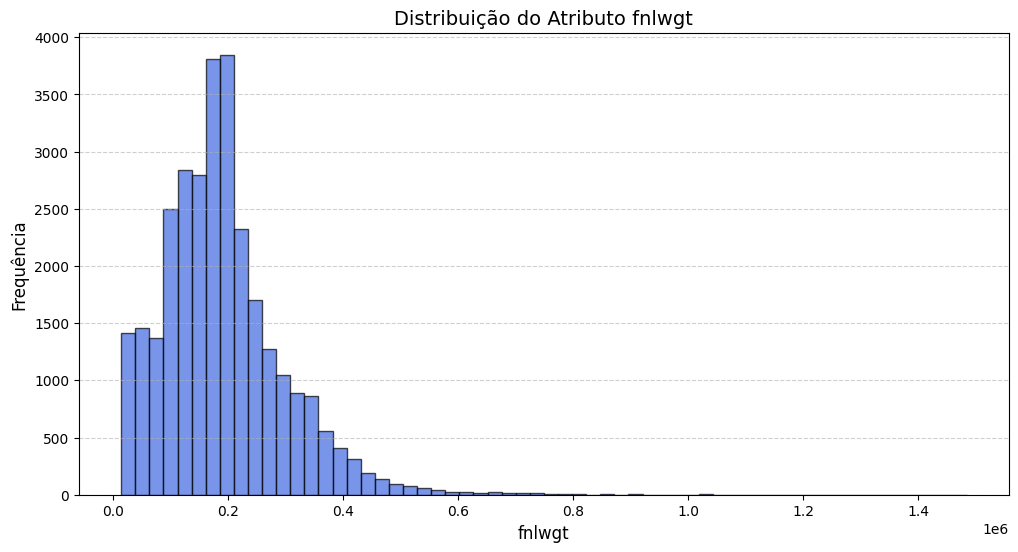

In [17]:
plt.figure(figsize=(12, 6)) 
plt.hist(dataset.fnlwgt , bins= 60,color='royalblue', edgecolor='black', alpha=0.7)

plt.title("Distribuição do Atributo fnlwgt", fontsize=14)
plt.xlabel("fnlwgt", fontsize=12)
plt.ylabel("Frequência", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()



#### 4.4- education: Nível de escolaridade do indivíduo ####


##### 4.4.1- Resumo #####

- Nível educacional mais alto alcançado por cada indivíduo. Ele é uma variável categórica.
- Indicador socioeconômico: O nível de educação pode estar fortemente correlacionado com a renda de uma pessoa.
- Relevante para modelos de machine learning: Pode ser um fator preditivo importante para determinar se um indivíduo ganha mais ou menos de 50K por ano.


##### 4.4.2- Dados #####

In [18]:
dataset.education.value_counts().sort_index()

education
10th             820
11th            1048
12th             377
1st-4th          151
5th-6th          288
7th-8th          557
9th              455
Assoc-acdm      1008
Assoc-voc       1307
Bachelors       5044
Doctorate        375
HS-grad         9840
Masters         1627
Preschool         45
Prof-school      542
Some-college    6678
Name: count, dtype: int64

##### 4.4.3- Gráfico #####

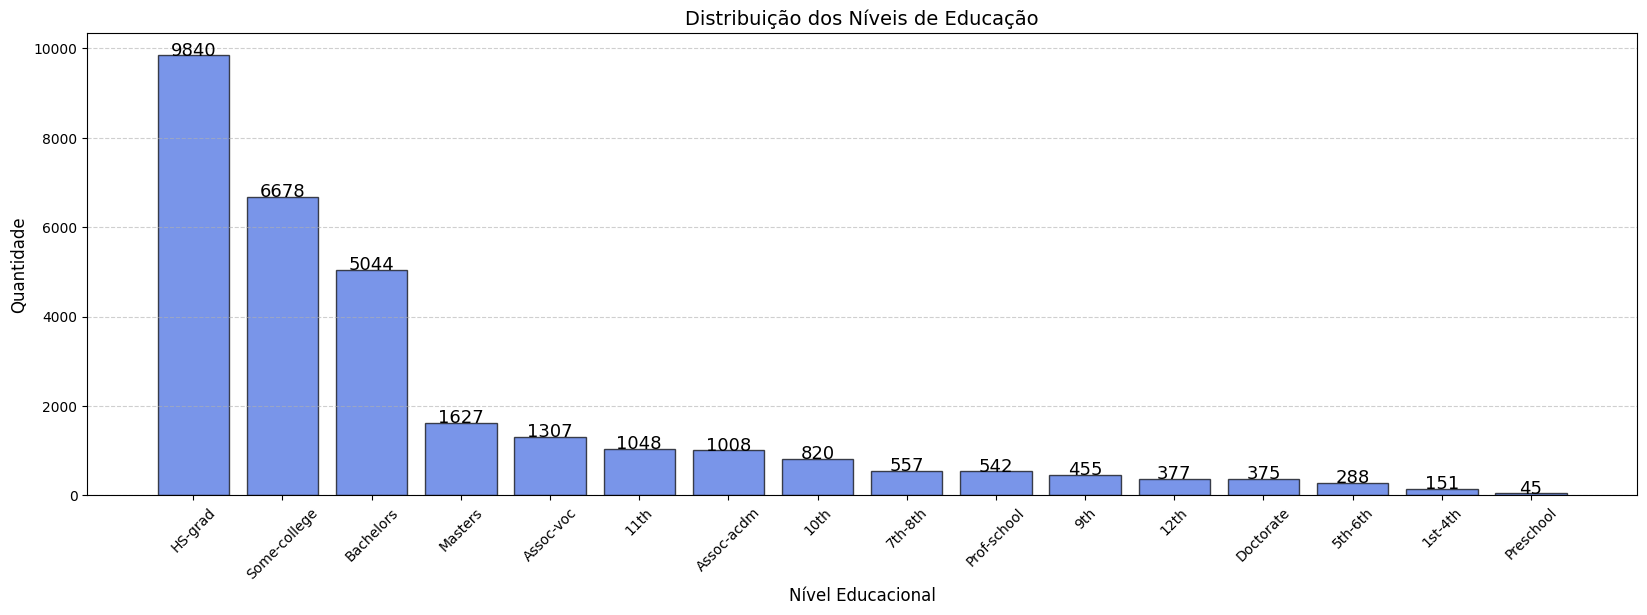

In [19]:
count_education = dataset.education.value_counts()
plt.figure(figsize=(20, 6))
plt.bar(count_education.index , count_education.values, color='royalblue', edgecolor='black', alpha=0.7)
plt.title("Distribuição dos Níveis de Educação", fontsize=14)
plt.xlabel("Nível Educacional", fontsize=12)
plt.ylabel("Quantidade", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
for i, valor in enumerate(count_education.values):
    plt.text(i, valor + 0.5, str(valor), ha='center', fontsize=13)
plt.show()

Níveis mais comuns de escolaridade
- HS-grad (Ensino Médio completo): É o nível com maior número de indivíduos, totalizando 9840 pessoas. Isso indica que a maioria da população atingiu esse nível de escolaridade.

- Some-college (Algum tempo de faculdade, mas sem diploma): Vem em segundo lugar, com 6678 pessoas, sugerindo que muitos iniciam a educação superior, mas não concluem.

- Bachelors (Bacharelado): Com 5044 pessoas, é o terceiro nível mais comum.

#### 4.5- education-num: Número de anos de educação alcançados (contínuo) ####

##### 4.5.1- Resumo #####

Representa o nível educacional de uma pessoa em formato numérico. Ele é uma versão transformada da variável education

- Cada nível de educação recebe um número correspondente, facilitando a análise quantitativa.
- Por exemplo, Preschool pode ter um valor baixo (1), enquanto Doctorate pode ter um valor alto (16).
- Essa codificação permite que modelos de machine learning interpretem a educação como uma variável numérica, sem necessidade de conversão manual.

| education-num | education    |
| ------------- | ------------ |
| 1             | Preschool    |
| 2             | 1st-4th      |
| 3             | 5th-6th      |
| 4             | 7th-8th      |
| 5             | 9th          |
| 6             | 10th         |
| 7             | 11th         |
| 8             | 12th         |
| 9             | HS-grad      |
| 10            | Some-college |
| 11            | Assoc-voc    |
| 12            | Assoc-acdm   |
| 13            | Bachelors    |
| 14            | Masters      |
| 15            | Prof-school  |
| 16            | Doctorate    |


##### 4.5.2- Dados #####

In [20]:
dataset['education-num'].value_counts()

education-num
9     9840
10    6678
13    5044
14    1627
11    1307
7     1048
12    1008
6      820
4      557
15     542
5      455
8      377
16     375
3      288
2      151
1       45
Name: count, dtype: int64

In [21]:
dataset['education-num'].describe()

count    30162.000000
mean        10.121312
std          2.549995
min          1.000000
25%          9.000000
50%         10.000000
75%         13.000000
max         16.000000
Name: education-num, dtype: float64

##### 4.5.3- Gráfico #####

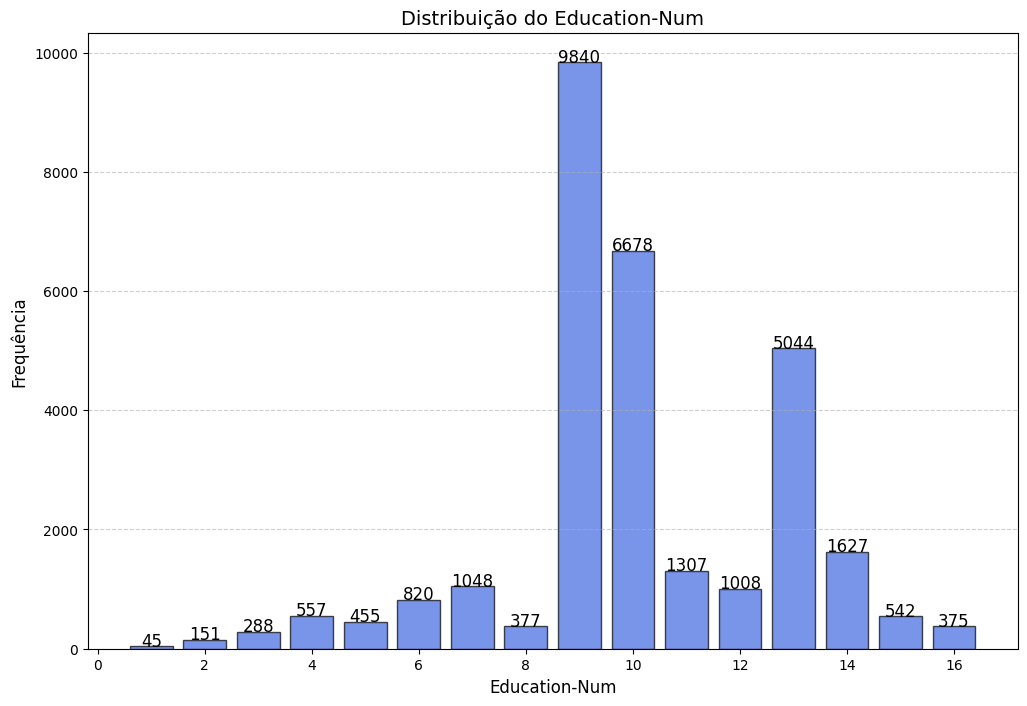

In [22]:
count_education_num = dataset['education-num'].value_counts().sort_index()
plt.figure(figsize=(12, 8))
plt.bar(count_education_num.index , count_education_num.values,color='royalblue', edgecolor='black', alpha=0.7)
plt.title("Distribuição do Education-Num", fontsize=14)
plt.xlabel("Education-Num", fontsize=12)
plt.ylabel("Frequência", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
for i, valor in enumerate(count_education_num.values):
    plt.text(count_education_num.index[i], valor + 0.5, str(valor), ha='center', fontsize=12)

plt.show()




Distribuição Centralizada no Ensino Médio
- O valor mais frequente é 9 (HS-grad) com 9840 ocorrências.

- Isso indica que a maioria dos adultos completou o ensino médio, mas não necessariamente avançou para o ensino superior.

- População majoritariamente educada até o ensino médio.

- Educação superior é comum, mas muitos não completam.

- Níveis muito baixos de educação (pré-escolar até 6ª série) são poucos.

#### 4.6- marital-status: Estado civil do indivíduo (categórico) ####

##### 4.6.1- Resumo #####

Representa o estado civil de cada indivíduo. Ele é uma variável categórica e pode incluir valores como:
- Never-married (Nunca casado)
- Married-civ-spouse (Casado legalmente)
- Divorced (Divorciado)
- Separated (Separado)
- Widowed (Viúvo)
- Married-spouse-absent (Casado, mas cônjuge ausente)
- Married-AF-spouse (Casado com cônjuge das Forças Armadas)


##### 4.6.2- Dados #####

In [23]:
dataset['marital-status'].value_counts().sort_index()

marital-status
Divorced                  4214
Married-AF-spouse           21
Married-civ-spouse       14065
Married-spouse-absent      370
Never-married             9726
Separated                  939
Widowed                    827
Name: count, dtype: int64

##### 4.6.3- Gráfico #####

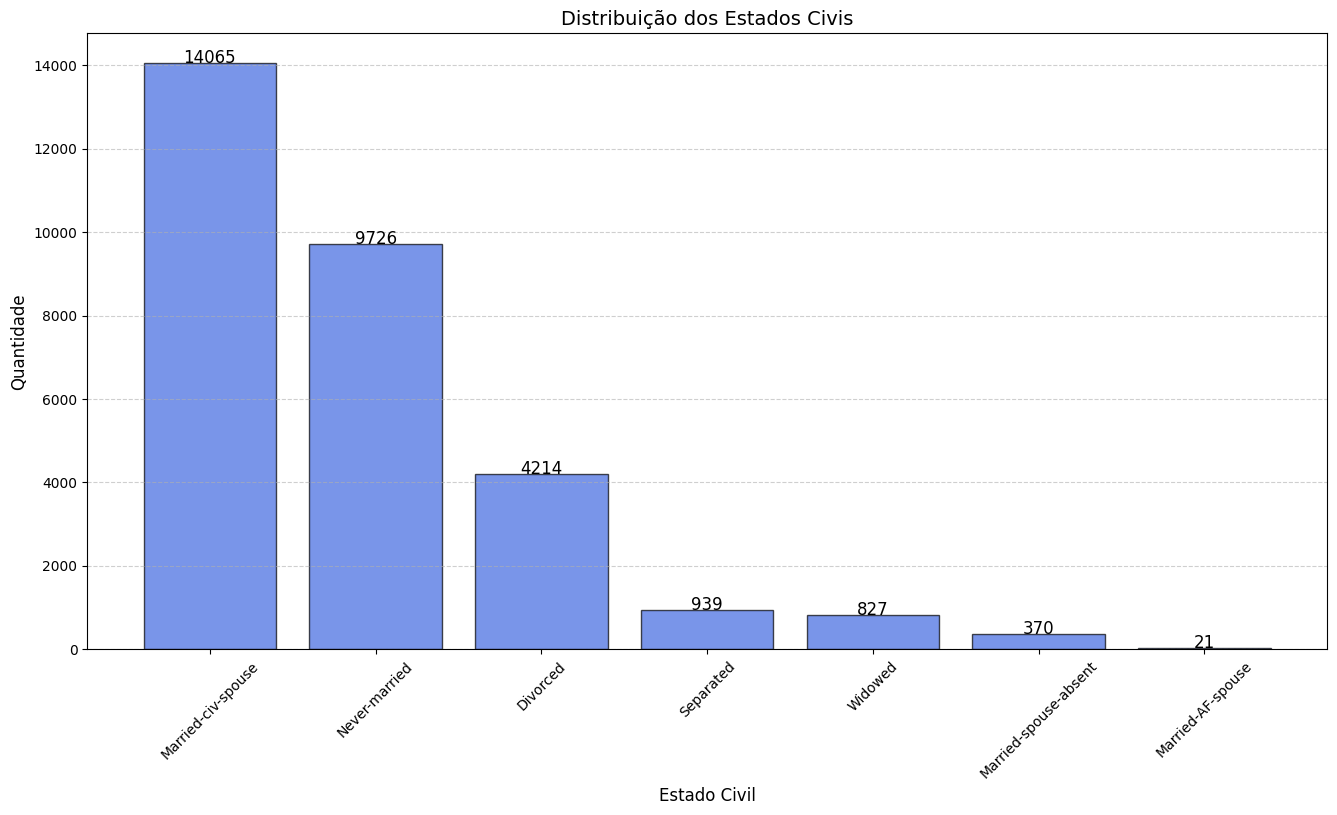

In [24]:
count_marital_status = dataset['marital-status'].value_counts()
plt.figure(figsize=(16, 8))
plt.bar(count_marital_status.index , count_marital_status.values,color='royalblue', edgecolor='black', alpha=0.7)
plt.title("Distribuição dos Estados Civis", fontsize=14)
plt.xlabel("Estado Civil", fontsize=12)
plt.ylabel("Quantidade", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
for i, valor in enumerate(count_marital_status.values):
    plt.text(i, valor + 0.5, str(valor), ha='center', fontsize=12)

plt.show()


#### 4.7- occupation: Ocupação do indivíduo (categórico) ####

##### 4.7.1- Resumo #####

Representa a ocupação profissional de cada indivíduo. Ele é uma variável categórica e pode incluir valores como:

- Tech-support (Suporte técnico)
- Craft-repair (Reparo artesanal)
- Other-service (Outros serviços)
- Sales (Vendas)
- Exec-managerial (Executivo/gerencial)
- Prof-specialty (Profissional especializado)
- Handlers-cleaners (Manutenção/limpeza)
- Machine-op-inspct (Operador de máquinas/inspeção)
- Adm-clerical (Administrativo/escritório)
- Farming-fishing (Agricultura/pesca)
- Transport-moving (Transporte)
- Priv-house-serv (Serviço doméstico)
- Protective-serv (Serviço de segurança)
- Armed-Forces (Forças Armadas).



##### 4.7.2- Dados #####

In [25]:
dataset.occupation.value_counts().sort_values()

occupation
Armed-Forces            9
Priv-house-serv       143
Protective-serv       644
Tech-support          912
Farming-fishing       989
Handlers-cleaners    1350
Transport-moving     1572
Machine-op-inspct    1966
Other-service        3212
Sales                3584
Adm-clerical         3721
Exec-managerial      3992
Craft-repair         4030
Prof-specialty       4038
Name: count, dtype: int64

##### 4.7.3- Gráfico #####

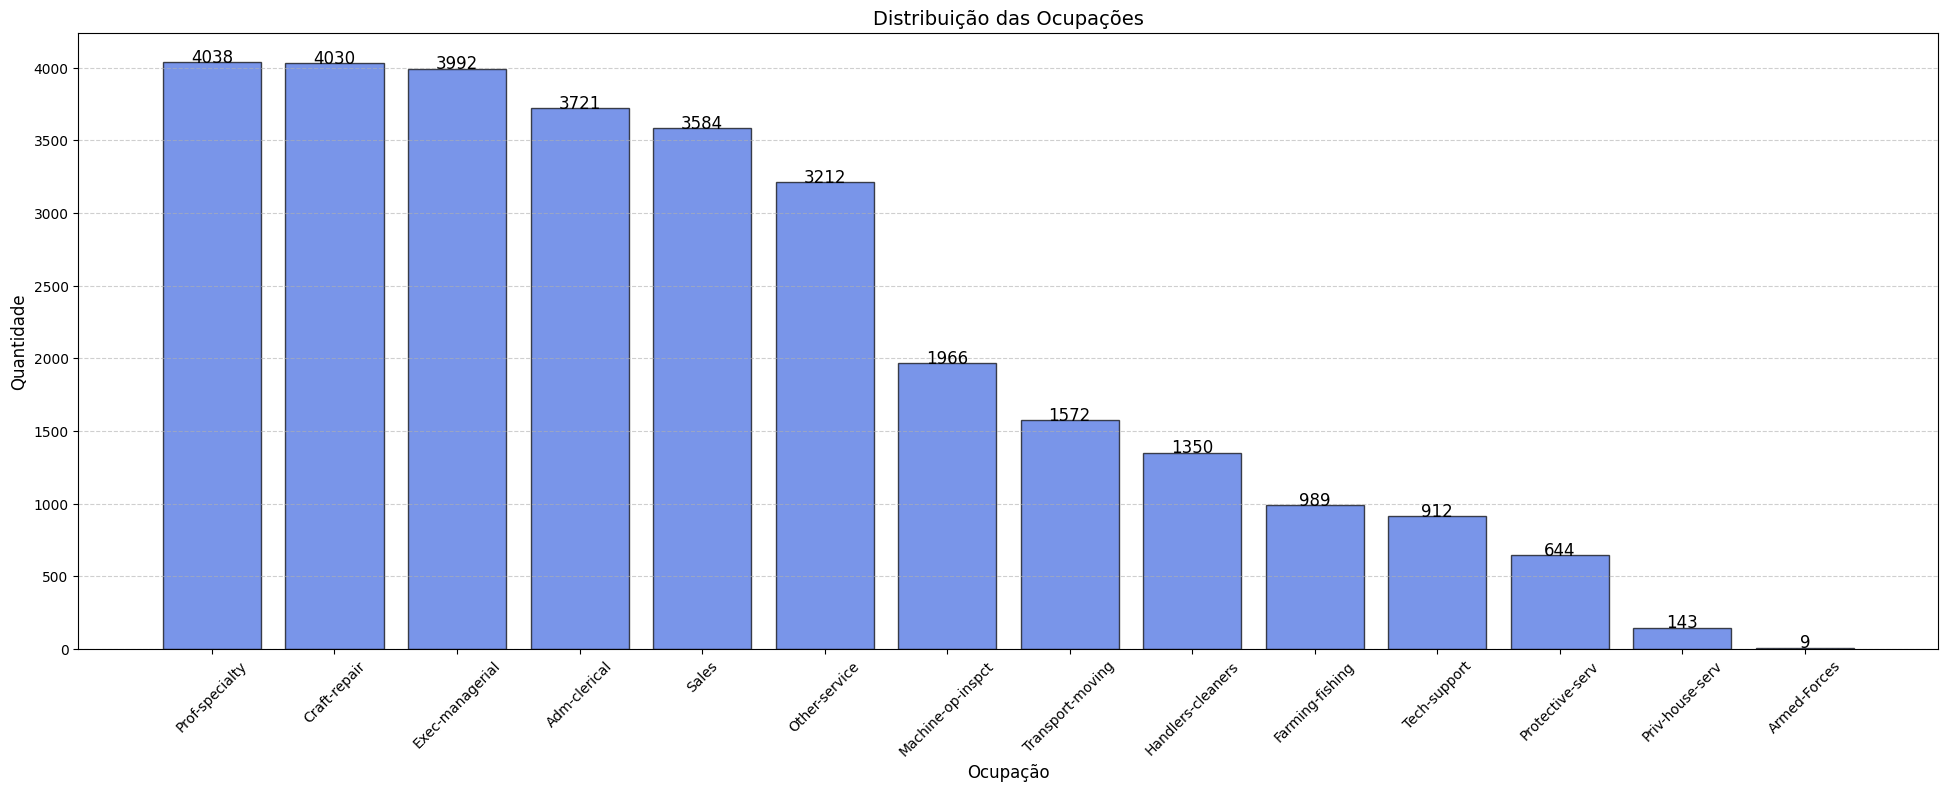

In [26]:
count_occupation = dataset.occupation.value_counts() 
plt.figure(figsize=(24, 8))
plt.bar(count_occupation.index , count_occupation.values,color='royalblue', edgecolor='black', alpha=0.7)
plt.title("Distribuição das Ocupações", fontsize=14)
plt.xlabel("Ocupação", fontsize=12)
plt.ylabel("Quantidade", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
for i, valor in enumerate(count_occupation.values):
    plt.text(i, valor + 0.5, str(valor), ha='center', fontsize=12)

plt.show()


As três categorias com maior número de registros são:

- Prof-specialty (4038) :Profissões especializadas como médicos, engenheiros, professores, etc.

- Craft-repair (4030) : Ocupações técnicas/manuais, como mecânicos, encanadores, carpinteiros.

- Exec-managerial (3992) : Cargos de chefia, gestão e administração.
-- Provavelmente correlacionado com renda mais alta e maior escolaridade.

#### 4.8- relationship: Relação familiar do indivíduo (categórico) ####

##### 4.8.1- Resumo #####

Descreve o papel do indivíduo dentro de uma família ou residência. Ele é uma variável categórica e pode incluir valores como:
- Wife (Esposa)
- Husband (Marido)
- Own-child (Filho próprio)
- Unmarried (Solteiro)
- Other-relative (Outro parente)
- Not-in-family (Não pertence a uma família)


Importância do atributo relationship
- Pode influenciar a renda: Pessoas casadas (como Husband e Wife) podem ter maior estabilidade financeira e, possivelmente, rendas mais altas.
- Complementa marital-status: Junto com o estado civil, ajuda a entender melhor a estrutura familiar do indivíduo.
- Relevante para modelos de machine learning: Pode ser um fator preditivo importante para determinar se um indivíduo ganha mais ou menos de 50K por ano.


##### 4.8.2- Dados #####

In [27]:
dataset.relationship.value_counts().sort_values()

relationship
Other-relative      889
Wife               1406
Unmarried          3212
Own-child          4466
Not-in-family      7726
Husband           12463
Name: count, dtype: int64

##### 4.8.3- Gráfico #####

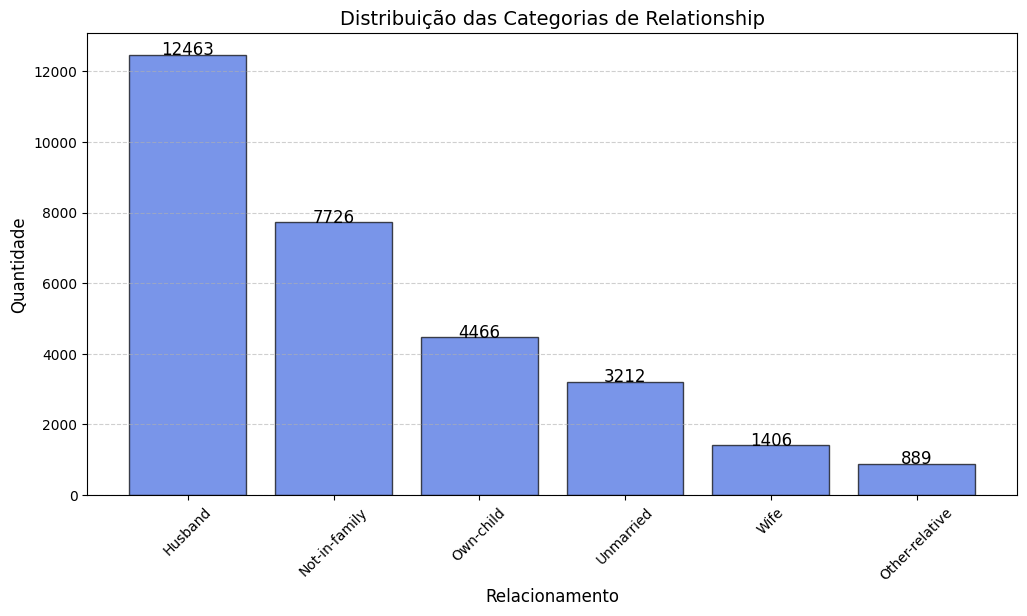

In [28]:
count_relationship = dataset.relationship.value_counts()
plt.figure(figsize=(12, 6))
plt.bar(count_relationship.index , count_relationship.values,color='royalblue', edgecolor='black', alpha=0.7)
plt.title("Distribuição das Categorias de Relationship", fontsize=14)
plt.xlabel("Relacionamento", fontsize=12)
plt.ylabel("Quantidade", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
for i, valor in enumerate(count_relationship.values):
    plt.text(i, valor + 0.5, str(valor), ha='center', fontsize=12)

plt.show()


Categorias mais frequentes
- Husband (12463): Representa a maior parte dos registros. Indica que a maioria dos indivíduos na base são homens casados, e provavelmente chefes de família.

- Not-in-family (7726): Indivíduos vivendo sozinhos ou em casas compartilhadas, sem relação familiar com os demais. Pode incluir jovens, solteiros ou pessoas que dividem moradia.

- Own-child (4466): Pessoas que são filhos ou filhas do chefe da família. Provavelmente pessoas mais jovens, em idade escolar ou início da vida adulta.

Interpretação
- Predominância de homens casados como chefes de família sugere uma estrutura familiar tradicional no dataset.

- Alta proporção de pessoas fora de núcleos familiares diretos (Not-in-family + Own-child) pode indicar: Jovens adultos vivendo sozinhos.

 - Baixa presença de mulheres na posição de esposa (wife) em relação a “husband” reforça viés historico do genero no mercado de trabalho.

#### 4.9 race: Raça do indivíduo (categórico) ####

##### 4.9.1- Resumo #####

Representa a raça declarada de cada indivíduo. Ele é uma variável categórica e pode incluir valores como:
- White (Branco)
- Black (Negro)
- Asian-Pac-Islander (Asiático ou das Ilhas do Pacífico)
- Amer-Indian-Eskimo (Indígena Americano ou Esquimó)
- Other (Outra)


- Pode influenciar a renda: Em algumas análises socioeconômicas, diferenças de renda podem ser observadas entre grupos raciais devido a fatores históricos e estruturais.
- Relevante para estudos de equidade: Essa variável pode ser usada para investigar disparidades salariais e possíveis vieses em modelos de aprendizado de máquina.
- Pode estar correlacionada com outras variáveis: Como ocupação, educação e estado civil.


##### 4.9.2- Dados #####

In [29]:
dataset.race.value_counts().sort_values()

race
Other                   231
Amer-Indian-Eskimo      286
Asian-Pac-Islander      895
Black                  2817
White                 25933
Name: count, dtype: int64

##### 4.9.3- Gráfico #####

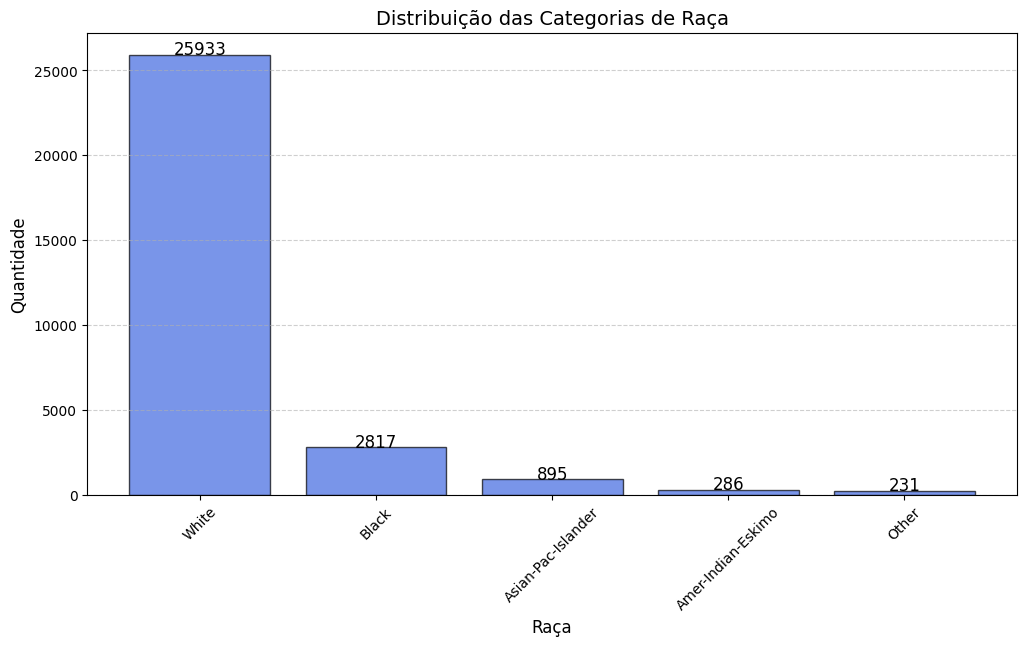

In [30]:
count_race = dataset.race.value_counts()
plt.figure(figsize=(12, 6))
plt.bar(count_race.index , count_race.values, color='royalblue', edgecolor='black', alpha=0.7)
plt.title("Distribuição das Categorias de Raça", fontsize=14)
plt.xlabel("Raça", fontsize=12)
plt.ylabel("Quantidade", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for i, valor in enumerate(count_race.values):
    plt.text(i, valor + 0.5, str(valor), ha='center', fontsize=12)

plt.show()

Categorias e Frequências
1. White — 25933 registros

- Claramente dominante no conjunto de dados.

- Representa a maior parte da população da base, o que pode introduzir viés estatístico nas análises.

2. Black — 2817 registros 

- Segunda maior categoria.

- Presença significativa, mas ainda substancialmente menor que a categoria majoritária.

3. Asian-Pac-Islander — 895 registros 

- Representação modesta.

- Pode ser importante analisar essa categoria separadamente por questões culturais e de renda.

4. Amer-Indian-Eskimo — 286 registros 

- Minoria expressiva, mas pequena em termos absolutos.

- Pode ser difícil tirar conclusões estatisticamente significativas com essa amostra.

5. Other — 231 registros 

- Categoria genérica que abrange demais grupos não especificados.

- Uso dessa categoria pode ocultar diversidades relevantes.

#### 4.10 sex: Sexo do indivíduo (categórico) ####

##### 4.10.1- Resumo #####

 Representa o gênero do indivíduo e é uma variável binária com os valores:
- Male (Masculino)
- Female (Feminino)


Importância do atributo sex
- Pode influenciar a renda: Estudos mostram que há diferenças salariais entre homens e mulheres em diversas áreas profissionais.
- Relevante para análises de equidade: Essa variável pode ser usada para investigar disparidades salariais e possíveis vieses em modelos de aprendizado de máquina.
- Pode estar correlacionada com outras variáveis: Como ocupação, horas trabalhadas por semana e estado civil.


##### 4.10.2- Dados #####

In [31]:
dataset.sex.value_counts().sort_values()

sex
Female     9782
Male      20380
Name: count, dtype: int64

##### 4.10.3- Gráfico #####

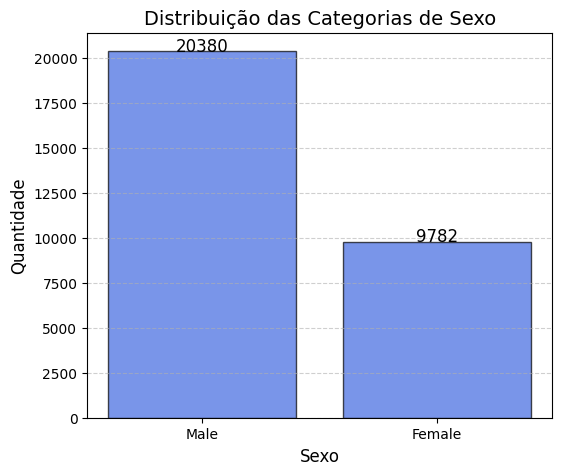

In [32]:
count_sex = dataset.sex.value_counts()
plt.figure(figsize=(6, 5))
plt.bar(count_sex.index , count_sex.values,color='royalblue', edgecolor='black', alpha = 0.7)
plt.title("Distribuição das Categorias de Sexo", fontsize=14)
plt.xlabel("Sexo", fontsize=12)
plt.ylabel("Quantidade", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
for i, valor in enumerate(count_sex.values):
    plt.text(i, valor + 0.5, str(valor), ha='center', fontsize=12)

plt.show()

- A amostra possui o dobro de homens em relação às mulheres.

- Esse desbalanceamento pode afetar modelos preditivos, especialmente em tarefas como classificação de renda, pois:

    - O modelo pode ser mais preciso para o grupo majoritário (homens).

    - Há risco de viés algorítmico, favorecendo um gênero.

- Quando cruzado com a variável income, o atributo sex pode revelar disparidades salariais entre homens e mulheres.

- Isso permite investigar questões de desigualdade de gênero no mercado de trabalho.

#### 4.11- capital-gain: Ganho de capital (contínuo) ####

##### 4.11.1- Resumo #####

Representa o ganho de capital de um indivíduo, ou seja, a renda obtida a partir da venda de ativos como ações, imóveis ou outros investimentos.
Importância do atributo capital-gain
- Pode influenciar a renda total: Pessoas que têm ganhos de capital elevados podem ter uma renda significativamente maior.
- Relevante para modelos de machine learning: Pode ser um fator preditivo importante para determinar se um indivíduo ganha mais ou menos de 50K por ano.
- Pode estar correlacionado com outras variáveis: Como ocupação, nível educacional e idade.


##### 4.11.2- Dados #####

In [33]:
dataset['capital-gain'].describe()

count    30162.000000
mean      1092.007858
std       7406.346497
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-gain, dtype: float64

1. Distribuição Extremamente Assimétrica
- Mediana = 0, e 75% dos dados são 0 — ou seja, mais de 75% das pessoas não tiveram nenhum ganho de capital.

- Isso indica uma distribuição altamente enviesada à direita, com muitos zeros e poucos valores muito altos.

2. Presença de Outliers
- O valor máximo de 99.999 é extremamente alto e bem distante da média (1.077) e do desvio padrão (7.385), indicando outliers severos.


##### 4.11.3- Gráfico #####

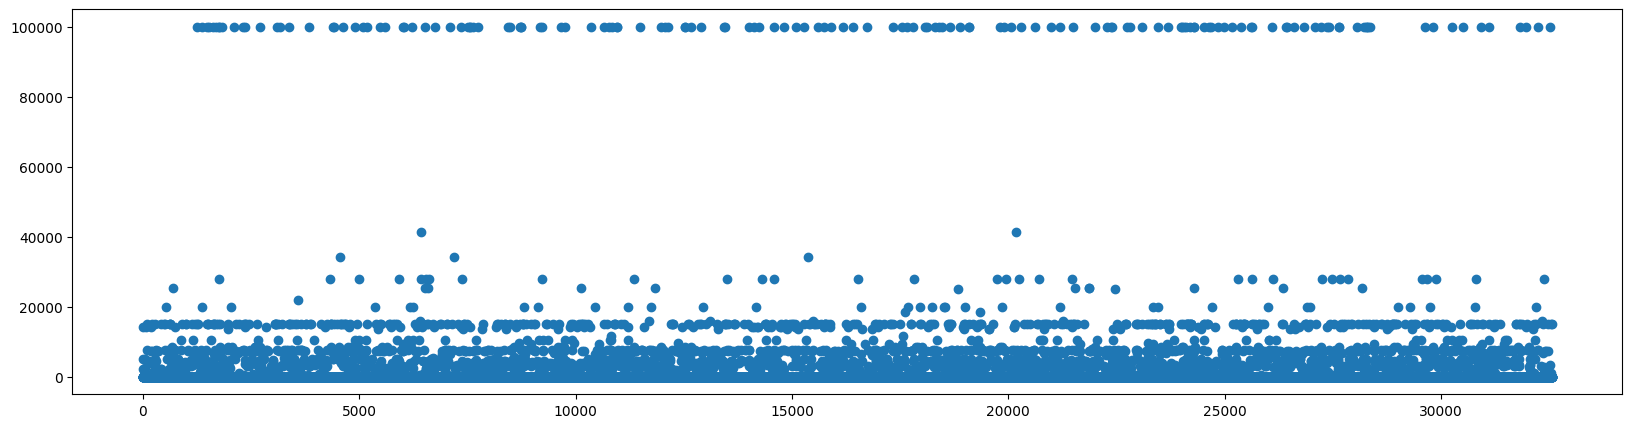

In [34]:
plt.figure(figsize=(20, 5))
plt.scatter(dataset['capital-gain'].index , dataset['capital-gain'].values)
plt.show()

- O alto número de zeros pode distorcer análises estatísticas e modelos preditivos.

- O uso dessa variável sem tratamento pode prejudicar desempenho de modelos e mascarar padrões reais.

#### 4.12- capital-loss: Perda de capital (contínuo) ####

##### 4.12.1- Resumo #####

Representa as perdas de capital de um indivíduo, ou seja, o valor perdido em investimentos, como ações ou imóveis, durante o ano.
Importância do atributo capital-loss
- Pode influenciar a renda total: Pessoas que tiveram perdas de capital podem ter uma renda líquida menor.
- Relevante para modelos de machine learning: Assim como capital-gain, essa variável pode ser um fator preditivo importante para determinar se um indivíduo ganha mais ou menos de 50K por ano.
- Pode estar correlacionado com outras variáveis: Como ocupação, nível educacional e idade.


##### 4.12.2- Dados #####

In [35]:
dataset['capital-loss'].describe()

count    30162.000000
mean        88.372489
std        404.298370
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4356.000000
Name: capital-loss, dtype: float64

Distribuição Extremamente Assimétrica
- Assim como na variável capital-gain, os valores de capital-loss são majoritariamente zero:

    - Mediana = 0

    - 75% dos valores são 0

- Isso indica que a grande maioria das pessoas não registrou perda de capital.

##### 4.12.3- Gráfico #####

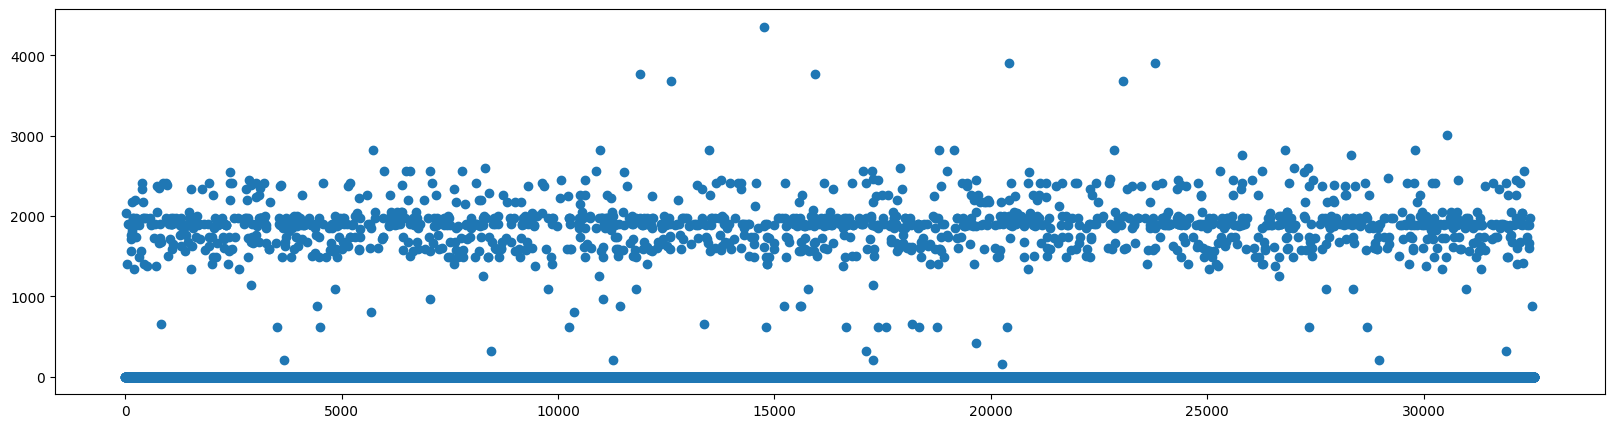

In [36]:
plt.figure(figsize=(20, 5))
plt.scatter(dataset['capital-loss'].index , dataset['capital-loss'].values)
plt.show()

#### 4.13- hours-per-week: Número de horas trabalhadas por semana (contínuo)  ####

##### 4.13.1- Resumo ##### 

Representa o número de horas que um indivíduo trabalha por semana. Ele é uma variável numérica contínua e pode variar bastante entre os registros.
Importância do atributo hours-per-week
- Pode influenciar a renda: Pessoas que trabalham mais horas por semana podem ter maior renda, especialmente em empregos que pagam por hora.
- Relevante para modelos de machine learning: Pode ser um fator preditivo importante para determinar se um indivíduo ganha mais ou menos de 50K por ano.
- Pode estar correlacionado com outras variáveis: Como ocupação, nível educacional e estado civil.

##### 4.13.2- Dados #####

In [37]:
dataset['hours-per-week'].value_counts()

hours-per-week
40    14251
50     2718
45     1753
60     1405
35     1184
      ...  
87        1
82        1
94        1
92        1
74        1
Name: count, Length: 94, dtype: int64

In [38]:
dataset['hours-per-week'].describe()

count    30162.000000
mean        40.931238
std         11.979984
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64

1. Forte Concentração em 40 Horas
- 25%, 50% e média estão todas em torno de 40 horas.

- Isso indica que o valor 40 horas por semana é o mais comum — provavelmente porque representa a jornada de trabalho padrão em muitos empregos formais.

- O valor máximo é 99, bem acima da média e dos quartis — o que sugere a presença de outliers (trabalhadores com carga horária excessiva).

- O mínimo de 1 hora também sugere a presença de pessoas com trabalho parcial, informal ou eventual.

##### 4.13.3- Gráfico #####

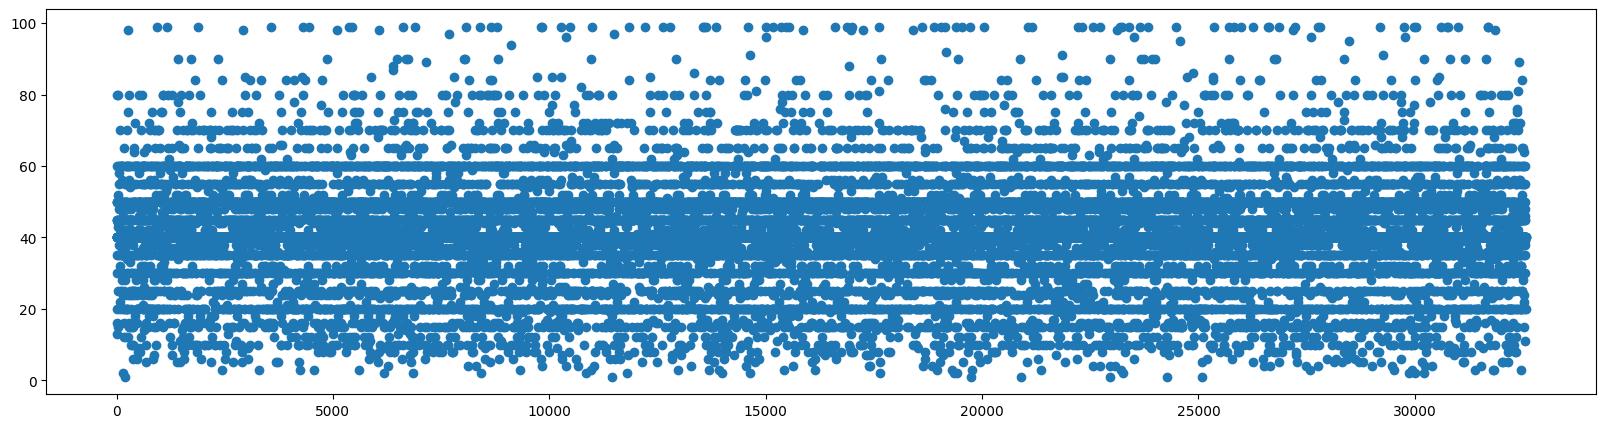

In [39]:
plt.figure(figsize=(20, 5))
plt.scatter(dataset['hours-per-week'].index , dataset['hours-per-week'].values)
plt.show()

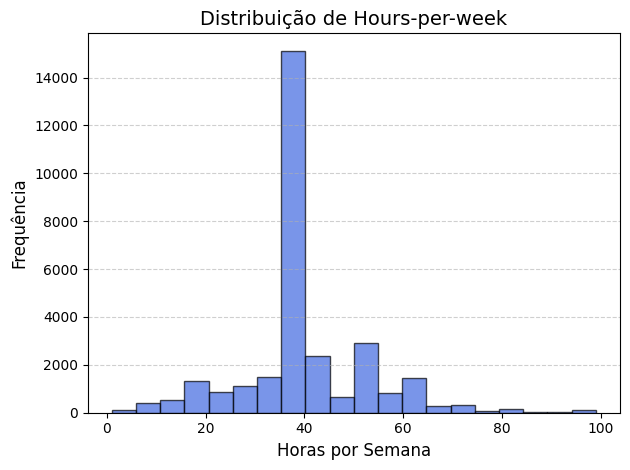

In [40]:
plt.hist(dataset['hours-per-week'], bins= 20, color='royalblue', edgecolor='black', alpha=0.7)

# Adicionando título e rótulos
plt.title("Distribuição de Hours-per-week", fontsize=14)
plt.xlabel("Horas por Semana", fontsize=12)
plt.ylabel("Frequência", fontsize=12)

# Ajustando o estilo do grid
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

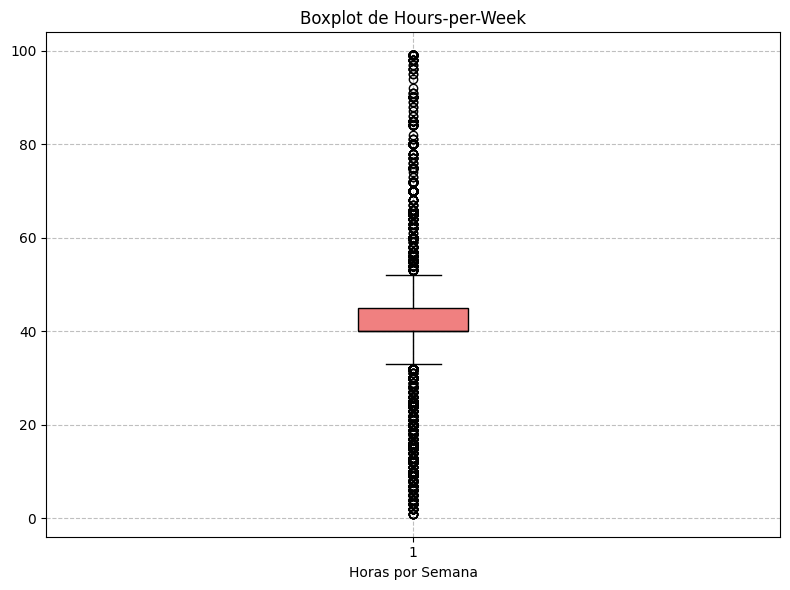

In [41]:
plt.figure(figsize=(8, 6))
plt.boxplot(dataset['hours-per-week'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightcoral', color='black'),
            medianprops=dict(color='black'))
plt.title('Boxplot de Hours-per-Week')
plt.xlabel('Horas por Semana')
plt.grid(True, linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()

#### 4.14- native-country: País de origem do indivíduo (categórico) ####

##### 4.14.1- Resumo #####

Representa o país de origem do indivíduo. Possui 42 categorias distintas. Ele é uma variável categórica e pode incluir valores como:
- United-States (Estados Unidos)
- Mexico (México)
- Canada (Canadá)
- Germany (Alemanha)
- Philippines (Filipinas)
- India (Índia)
- China (China)
- Other (Outro país)



Importância do atributo native-country
- Pode influenciar a renda: O país de origem pode estar relacionado a oportunidades econômicas e acesso ao mercado de trabalho.
- Relevante para modelos de machine learning: Pode ser um fator preditivo importante, especialmente em estudos sobre imigração e impacto socioeconômico.
- Pode estar correlacionado com outras variáveis: Como ocupação, nível educacional e capital-gain.


##### 4.14.2- Dados #####

In [42]:
dataset['native-country'].value_counts().sort_index()

native-country
Cambodia                         18
Canada                          107
China                            68
Columbia                         56
Cuba                             92
Dominican-Republic               67
Ecuador                          27
El-Salvador                     100
England                          86
France                           27
Germany                         128
Greece                           29
Guatemala                        63
Haiti                            42
Holand-Netherlands                1
Honduras                         12
Hong                             19
Hungary                          13
India                           100
Iran                             42
Ireland                          24
Italy                            68
Jamaica                          80
Japan                            59
Laos                             17
Mexico                          610
Nicaragua                        33
Outlying-US(G

##### 4.14.3- Gráfico #####

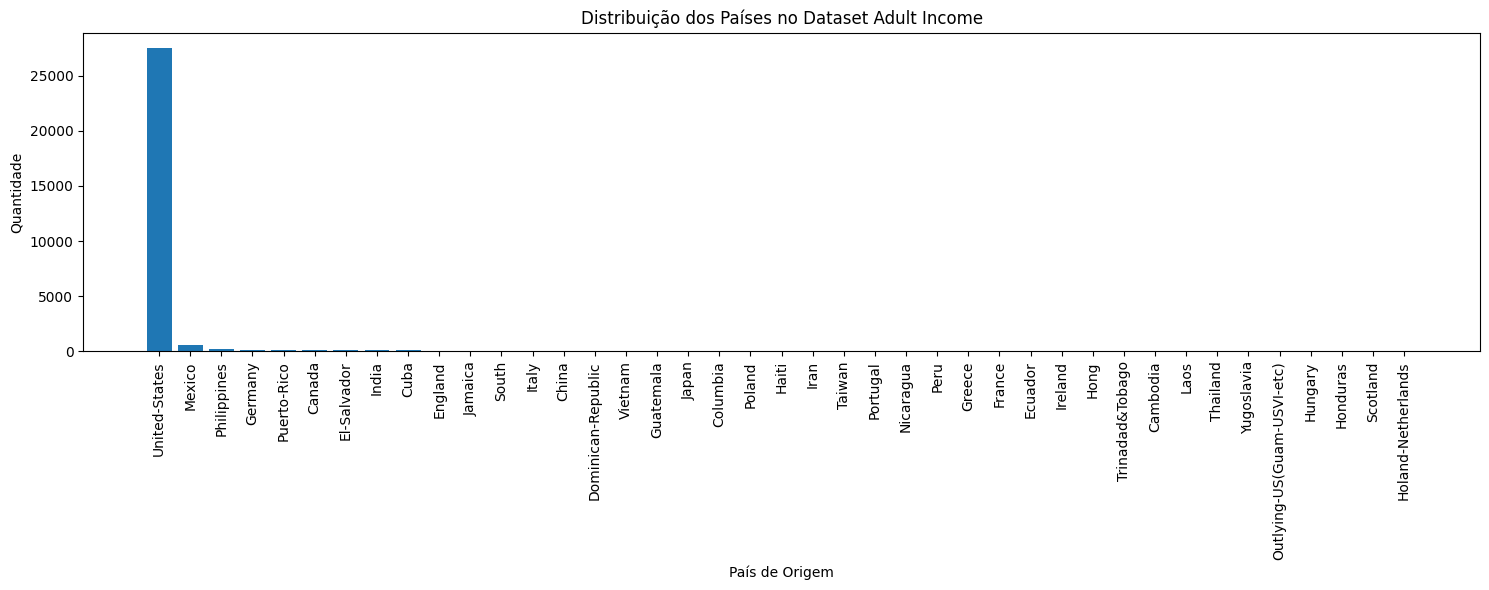

In [43]:
# Contagem dos países
count_native_country = dataset["native-country"].value_counts()

# Criando o gráfico
plt.figure(figsize=(15, 6))
plt.bar(count_native_country.index, count_native_country.values)

# Rotacionando os nomes dos países para melhor visualização
plt.xticks(rotation=90)
plt.xlabel("País de Origem")
plt.ylabel("Quantidade")
plt.title("Distribuição dos Países no Dataset Adult Income")
plt.tight_layout()
plt.show()

- Estados Unidos (United-States) domina o conjunto de dados:

    - Com cerca de 29.000 registros, representa uma massiva maioria dos dados.

    - Isso indica que o dataset tem um forte viés geográfico, voltado para a realidade norte-americana.

- Outros países aparecem em quantidades extremamente reduzidas:

    - México, Filipinas, Alemanha e Canadá aparecem, mas com frequência muito pequena.

    - A maioria dos demais países tem menos de 100 registros cada.

#### 4.15- income: Variável alvo (categórico) ####

##### 4.15.1- Resumo #####

É a variável-alvo do conjunto de dados. Ele indica se um indivíduo ganha mais ou menos de 50K por ano, sendo uma variável categórica binária com os seguintes valores:
- <=50K: Indivíduos que ganham até 50 mil dólares por ano.
- >50K: Indivíduos que ganham mais de 50 mil dólares por ano.


##### 4.15.2- Dados #####

In [44]:
dataset.income.value_counts()

income
<=50K    22654
>50K      7508
Name: count, dtype: int64

In [45]:
print(f'O percentual de pessoal que ganham >50K é : {((dataset['income'] == '>50K').sum() / dataset['income'].count()*100)}')
print(f'O percentual de pessoal que ganham <=50K é : {((dataset['income'] != '>50K').sum() / dataset['income'].count()*100)}')


O percentual de pessoal que ganham >50K é : 24.892248524633644
O percentual de pessoal que ganham <=50K é : 75.10775147536636


##### 4.15.3- Gráfico #####

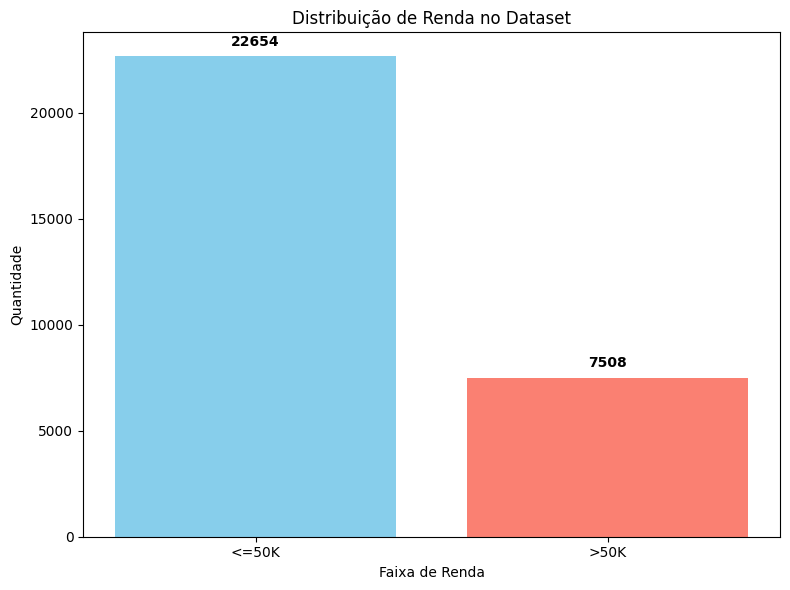

In [46]:
# Contagem das classes de income
count_income = dataset['income'].value_counts()

# Plot
plt.figure(figsize=(8, 6))
plt.bar(count_income.index, count_income.values, color=['skyblue', 'salmon'])

# Adiciona os rótulos
for i, v in enumerate(count_income.values):
    plt.text(i, v + 500, str(v), ha='center', fontweight='bold')

# Configurações
plt.xlabel("Faixa de Renda")
plt.ylabel("Quantidade")
plt.title("Distribuição de Renda no Dataset")
plt.tight_layout()
plt.show()


### 5.-**Resumo dos Atributos**

Com base nas análises que você já foram feitas até aqui (gráficos, estatísticas e distribuição de dados), abaixo são as considerações que vamos com os atributos antes de aplicar os algoritmos de classificação 
1. Atributos a MANTER (com ou sem pré-processamento):
- age , hours-per-week: -> normalizar.

- education,workclass,marital-status, occupation, relationship, race, sex, native-country: -> Transformar em numérico.

- income: Target. JManter com está.

2. Atributos a MODIFICAR:
- capital-gain / capital-loss:

    - Altamente enviesados (muitos zeros, poucos valores altos).


- Criar uma variável binária indicando se teve ganho/perda (capital_gain_flag).

3. Atributos a EXCLUIR (opcional):

- fnlwgt: como visto variável estatisica sem muita relevância

### 6.-**Transformação dos Atributos**

#### 6.1- ***Transformando os atributos 'capital-gain' e 'capital-loss' em variáveis binárias***



*Mapeamento*
- capital-gain → 1 se > 0, senão 0

- capital-loss → 1 se > 0, senão 0

In [47]:
# Cria uma cópia do dataset original
dataset2 = dataset.copy()
# Capital Gain: 1 se teve ganho, 0 se não teve
dataset2['capital_gain_bin'] = dataset2['capital-gain'].apply(lambda x: 1 if x > 0 else 0)

# Capital Loss: 1 se teve perda, 0 se não teve
dataset2['capital_loss_bin'] = dataset2['capital-loss'].apply(lambda x: 1 if x > 0 else 0)

#  removendo as colunas originais
dataset2.drop(['capital-gain', 'capital-loss'], axis=1, inplace=True)
dataset2.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,income,capital_gain_bin,capital_loss_bin
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,40,United-States,<=50K,1,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,13,United-States,<=50K,0,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,40,United-States,<=50K,0,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,40,United-States,<=50K,0,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,40,Cuba,<=50K,0,0


#### 6.2- ***Excluindo o atributo 'fnlwgt'***

In [48]:
dataset2.drop('fnlwgt', axis=1, inplace=True)
dataset2.head()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,income,capital_gain_bin,capital_loss_bin
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,40,United-States,<=50K,1,0
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,13,United-States,<=50K,0,0
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,40,United-States,<=50K,0,0
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,40,United-States,<=50K,0,0
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,40,Cuba,<=50K,0,0


#### 6.3- ***Transformar os atributos categóricos em numericos***

In [49]:
# Lista das colunas categóricas
colunas_categoricas = [
    'education', 'workclass', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'native-country'
]

# Aplicando LabelEncoder e exibindo os mapeamentos
for col in colunas_categoricas:
    le = LabelEncoder()
    dataset2[col] = le.fit_transform(dataset2[col])
    
    # Mostrar mapeamento
    mapeamento = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'\nCodificação da coluna "{col}":')
    for categoria, codigo in mapeamento.items():
        print(f'  {categoria} -> {codigo}')


Codificação da coluna "education":
  10th -> 0
  11th -> 1
  12th -> 2
  1st-4th -> 3
  5th-6th -> 4
  7th-8th -> 5
  9th -> 6
  Assoc-acdm -> 7
  Assoc-voc -> 8
  Bachelors -> 9
  Doctorate -> 10
  HS-grad -> 11
  Masters -> 12
  Preschool -> 13
  Prof-school -> 14
  Some-college -> 15

Codificação da coluna "workclass":
  Federal-gov -> 0
  Local-gov -> 1
  Private -> 2
  Self-emp-inc -> 3
  Self-emp-not-inc -> 4
  State-gov -> 5
  Without-pay -> 6

Codificação da coluna "marital-status":
  Divorced -> 0
  Married-AF-spouse -> 1
  Married-civ-spouse -> 2
  Married-spouse-absent -> 3
  Never-married -> 4
  Separated -> 5
  Widowed -> 6

Codificação da coluna "occupation":
  Adm-clerical -> 0
  Armed-Forces -> 1
  Craft-repair -> 2
  Exec-managerial -> 3
  Farming-fishing -> 4
  Handlers-cleaners -> 5
  Machine-op-inspct -> 6
  Other-service -> 7
  Priv-house-serv -> 8
  Prof-specialty -> 9
  Protective-serv -> 10
  Sales -> 11
  Tech-support -> 12
  Transport-moving -> 13

Codificaçã

In [50]:
# Reorganizar as colunas para que 'income' fique por último
colunas = [col for col in dataset2.columns if col != 'income']
colunas.append('income')
dataset2 = dataset2[colunas]

dataset2.head()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,capital_gain_bin,capital_loss_bin,income
0,39,5,9,13,4,0,1,4,1,40,38,1,0,<=50K
1,50,4,9,13,2,3,0,4,1,13,38,0,0,<=50K
2,38,2,11,9,0,5,1,4,1,40,38,0,0,<=50K
3,53,2,1,7,2,5,0,2,1,40,38,0,0,<=50K
4,28,2,9,13,2,9,5,2,0,40,4,0,0,<=50K


#### 6.4- ***Transformando o Target -> 'income' em binário***

In [51]:
print(dataset2['income'].unique())


['<=50K' '>50K']


In [52]:
# Transformando a variável income diretamente no dataset2
dataset2['income'] = dataset2['income'].apply(lambda x: 1 if x.strip() == '>50K' else 0)



In [53]:
dataset2.income.value_counts()

income
0    22654
1     7508
Name: count, dtype: int64

### 7.- ***MODIFICAÇÕES REALIZADAS NO DATASET ORIGINAL***

1. Resumo das Modificações Realizadas:
Atributo	Ação Realizada
- fnlwgt	→    Removido
- capital-gain	Transformado em binário → capital_gain_bin
- capital-loss	Transformado em binário → capital_loss_bin
- Atributos categóricos (education, workclass, etc.)	Codificados com LabelEncoder
- income Transformado em binário


Validação :

- Todas as variáveis numéricas (inteiras ou binárias);

- Nenhum valor nulo (por conta do dropna);

- Atributo alvo (income) com duas classes: <=50K e >50K.



In [54]:
dataset2.head()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,capital_gain_bin,capital_loss_bin,income
0,39,5,9,13,4,0,1,4,1,40,38,1,0,0
1,50,4,9,13,2,3,0,4,1,13,38,0,0,0
2,38,2,11,9,0,5,1,4,1,40,38,0,0,0
3,53,2,1,7,2,5,0,2,1,40,38,0,0,0
4,28,2,9,13,2,9,5,2,0,40,4,0,0,0


In [55]:
dataset2.dtypes

age                 int64
workclass           int64
education           int64
education-num       int64
marital-status      int64
occupation          int64
relationship        int64
race                int64
sex                 int64
hours-per-week      int64
native-country      int64
capital_gain_bin    int64
capital_loss_bin    int64
income              int64
dtype: object

In [56]:
dataset2.describe()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,capital_gain_bin,capital_loss_bin,income
count,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000
mean,38.437902,2.199324,10.333764,10.121312,2.580134,5.959850,1.418341,3.678602,0.675685,40.931238,36.382567,0.084146,0.047311,0.248922
std,13.134665,0.953925,3.812292,2.549995,1.498016,4.029566,1.601338,0.834709,0.468126,11.979984,6.105372,0.277611,0.212307,0.432396
min,17.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,2.000000,9.000000,9.000000,2.000000,2.000000,0.000000,4.000000,0.000000,40.000000,38.000000,0.000000,0.000000,0.000000
50%,37.000000,2.000000,11.000000,10.000000,2.000000,6.000000,1.000000,4.000000,1.000000,40.000000,38.000000,0.000000,0.000000,0.000000
75%,47.000000,2.000000,12.000000,13.000000,4.000000,9.000000,3.000000,4.000000,1.000000,45.000000,38.000000,0.000000,0.000000,0.000000
max,90.000000,6.000000,15.000000,16.000000,6.000000,13.000000,5.000000,4.000000,1.000000,99.000000,40.000000,1.000000,1.000000,1.000000


### 8.- **Salvando (Exportando) o Dataframe Tratado**

In [57]:
dataset2.to_csv('adult_income_tratado.csv', sep=';', index=False)

## 2. Protocolo de Comparação

### Preparação e Divisão da Base de Dados

A correta preparação e divisão da base de dados são etapas fundamentais para garantir a validade dos resultados obtidos na comparação dos classificadores. Nesta atividade, o dataset foi dividido em conjuntos de treinamento e teste utilizando a técnica de validação cruzada estratificada com 5 folds. 

Esse método assegura que cada fold possua uma distribuição semelhante da variável alvo, reduzindo o viés e garantindo uma avaliação mais robusta dos modelos. Além disso, o uso da validação cruzada minimiza o risco de overfitting, permitindo que cada amostra seja utilizada tanto para treino quanto para teste, proporcionando uma visão mais completa do desempenho dos classificadores.

### Métricas de Avaliação

Para avaliar o desempenho dos classificadores, foram utilizadas as seguintes métricas:

* **Acurácia:** Proporção de previsões corretas em relação ao total de previsões. Indica a performance geral do modelo, mas pode ser enganosa em datasets desbalanceados.

* **Precisão:** Proporção de previsões positivas corretas em relação ao total de previsões positivas. É importante quando o custo de um falso positivo é alto.

* **Recall:** Proporção de previsões positivas corretas em relação ao total de positivos reais. Essencial em situações onde a identificação correta dos positivos é prioritária.

* **F1-score:** Média harmônica entre precisão e recall, equilibrando os dois aspectos. Ideal para datasets desbalanceados.

* **AUC-ROC:** Área sob a curva ROC, que avalia a capacidade do modelo em distinguir entre classes. Quanto mais próximo de 1, melhor a separação entre as classes positiva e negativa.

### Procedimentos Estatísticos para Comparação

Para avaliar se as diferenças de desempenho entre os classificadores são estatisticamente significativas, foram aplicados os testes recomendados por Demšar:

* **Teste de Friedman:** Utilizado para detectar diferenças significativas entre os classificadores em múltiplos folds. Este teste não pressupõe normalidade dos dados e é adequado para a comparação de mais de dois classificadores.

* **Teste de Nemenyi:** Aplicado como um post-hoc após o teste de Friedman. Ele permite identificar quais pares de classificadores apresentam diferenças significativas, comparando as médias dos ranks dos modelos. Quanto maior a diferença entre os ranks, maior a evidência de que os desempenhos são significativamente diferentes.

## 3. Execução da Comparação

### Implementação e Teste

A execução da comparação dos classificadores envolve a implementação e ajuste dos parâmetros dos modelos MLP, LVQ, KNN, SVM, Árvore de Decisão e Random Forest. 

#### 🔃 Carregamento e Pré-processamento dos Dados

In [58]:
# Importações necessárias
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
from random import seed, randrange
from math import sqrt
import scikit_posthocs as sp
from scipy.stats import friedmanchisquare
import seaborn as sns
import matplotlib.pyplot as plt

In [59]:
# Carregar a base (suponha que está em .csv)
df = pd.read_csv("adult_income_tratado.csv", sep = ';')

# Separar features e target
X = df.drop("income", axis=1).values
y = df["income"].values


#### 🏋️‍♂️ Treinamento e Avaliação dos Classificadores

In [60]:
# Implementação do LVQ
class LVQ:
    def __init__(self, n_codebooks=15, lrate=0.3, epochs=50, seed_val=1):
        self.n_codebooks = n_codebooks
        self.lrate = lrate
        self.epochs = epochs
        self.seed_val = seed_val
        self.codebooks = []

    def euclidean_distance(self, row1, row2):
        return sqrt(sum((row1[i] - row2[i])**2 for i in range(len(row1)-1)))

    def get_bmu(self, codebooks, test_row):
        distances = [(codebook, self.euclidean_distance(codebook, test_row)) for codebook in codebooks]
        distances.sort(key=lambda x: x[1])
        return distances[0][0]

    def train_codebooks(self, train):
        seed(self.seed_val)
        self.codebooks = [train[randrange(len(train))] for _ in range(self.n_codebooks)]

        for epoch in range(self.epochs):
            rate = self.lrate * (1.0 - (epoch / float(self.epochs)))
            for row in train:
                bmu = self.get_bmu(self.codebooks, row)
                for i in range(len(row)-1):
                    error = row[i] - bmu[i]
                    if bmu[-1] == row[-1]:
                        bmu[i] += rate * error
                    else:
                        bmu[i] -= rate * error

    def predict(self, row):
        bmu = self.get_bmu(self.codebooks, row)
        return bmu[-1]

    def fit(self, X, y):
        dataset = np.hstack((X, y.reshape(-1, 1))).tolist()
        self.train_codebooks(dataset)

    def predict_batch(self, X):
        return [self.predict(row) for row in X]


In [61]:
# Lista de classificadores
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "MLP": MLPClassifier(max_iter=500, random_state=42),
    "LVQ": LVQ()
}

# Função para avaliar classificadores
def avaliar_modelos(models, X, y):
    results = []
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for name, model in models.items():
        acc, prec, rec, f1, auc = [], [], [], [], []

        for train_idx, test_idx in skf.split(X, y):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            if name == "LVQ":
                model.fit(X_train, y_train)
                y_pred = model.predict_batch(X_test)
            else:
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)

            acc.append(accuracy_score(y_test, y_pred))
            prec.append(precision_score(y_test, y_pred))
            rec.append(recall_score(y_test, y_pred))
            f1.append(f1_score(y_test, y_pred))

            if hasattr(model, "predict_proba"):
                y_prob = model.predict_proba(X_test)[:, 1]
                auc.append(roc_auc_score(y_test, y_prob))
            elif name == "LVQ":
                auc.append(0)  # LVQ não possui probabilidade
            else:
                auc.append(roc_auc_score(y_test, model.decision_function(X_test)))

        results.append({
            "Classificador": name,
            "Acurácia": np.mean(acc),
            "Precisão": np.mean(prec),
            "Recall": np.mean(rec),
            "F1-score": np.mean(f1),
            "AUC-ROC": np.mean(auc)
        })

    return pd.DataFrame(results)


In [62]:
# Executar a avaliação
df_resultados = avaliar_modelos(models, X, y)
print(df_resultados)

c:\Users\negre\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\negre\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\negre\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

   Classificador  Acurácia  Precisão    Recall  F1-score   AUC-ROC
0  Decision Tree  0.784895  0.570560  0.550079  0.560104  0.727847
1  Random Forest  0.823288  0.664259  0.586707  0.623067  0.874081
2            SVM  0.806180  0.710338  0.374268  0.490142  0.837942
3            KNN  0.794875  0.595538  0.548882  0.571246  0.813578
4            MLP  0.825807  0.691778  0.586586  0.622553  0.889080
5            LVQ  0.751078  0.000000  0.000000  0.000000  0.000000


c:\Users\negre\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### 🔬 Testes Estatísticos de Friedman e Nemenyi

In [63]:
# Função para avaliar classificadores com métricas por fold
def avaliar_modelos_completo(models, X, y):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    resultados_fold = {
        "Modelo": [],
        "Fold": [],
        "Acuracia": [],
        "Precisao": [],
        "Recall": [],
        "F1": [],
        "AUC": []
    }

    for name, model in models.items():
        for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y)):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            if name == "LVQ":
                model.fit(X_train, y_train)
                y_pred = model.predict_batch(X_test)
                y_prob = [0] * len(y_test)  # LVQ não possui predict_proba
            else:
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)

            resultados_fold["Modelo"].append(name)
            resultados_fold["Fold"].append(fold_idx + 1)
            resultados_fold["Acuracia"].append(accuracy_score(y_test, y_pred))
            resultados_fold["Precisao"].append(precision_score(y_test, y_pred))
            resultados_fold["Recall"].append(recall_score(y_test, y_pred))
            resultados_fold["F1"].append(f1_score(y_test, y_pred))
            resultados_fold["AUC"].append(roc_auc_score(y_test, y_prob))

    return pd.DataFrame(resultados_fold)

In [64]:
# Executar a avaliação
df_folds = avaliar_modelos_completo(models, X, y)
df_folds.head(30)

c:\Users\negre\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\negre\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\negre\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

,Modelo,Fold,Acuracia,Precisao,Recall,F1,AUC
0,Decision Tree,1,0.783192,0.565718,0.555925,0.560779,0.725584
1,Decision Tree,2,0.783192,0.566438,0.550599,0.558406,0.727751
2,Decision Tree,3,0.785809,0.573747,0.541639,0.557231,0.728521
3,Decision Tree,4,0.780504,0.561246,0.540306,0.550577,0.722972
4,Decision Tree,5,0.787798,0.576657,0.555925,0.566102,0.730177
5,Random Forest,1,0.825460,0.667412,0.595872,0.629617,0.873746
6,Random Forest,2,0.818167,0.649667,0.585220,0.615762,0.869189
7,Random Forest,3,0.833389,0.691654,0.596269,0.640429,0.877624
8,Random Forest,4,0.814987,0.642910,0.576949,0.608146,0.863347
9,Random Forest,5,0.831399,0.684411,0.599201,0.638978,0.882625


### Análise dos Resultados

Cada classificador foi treinado e testado utilizando a validação cruzada estratificada com 5 folds, garantindo que cada instância do dataset fosse utilizada tanto para treino quanto para teste. 

Os resultados das métricas de avaliação foram então coletados e analisados, permitindo identificar os modelos com melhor desempenho em termos de acurácia, precisão, recall, F1-score e AUC-ROC. 

Em seguida, os procedimentos estatísticos foram aplicados para validar a significância das diferenças observadas nos desempenhos dos classificadores, proporcionando uma análise detalhada e fundamentada das variações observadas.

#### 🔍 Visualização dos Testes Estatísticos de Friedman e Nemenyi


🔎 Teste para: Acuracia
Friedman χ² = 23.5143, p = 0.0003
➡️ Diferença significativa. Teste de Nemenyi:


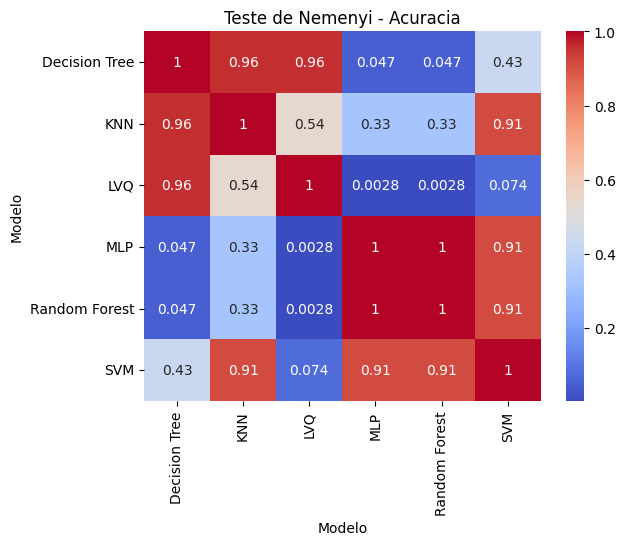


🔎 Teste para: Precisao
Friedman χ² = 22.4857, p = 0.0004
➡️ Diferença significativa. Teste de Nemenyi:


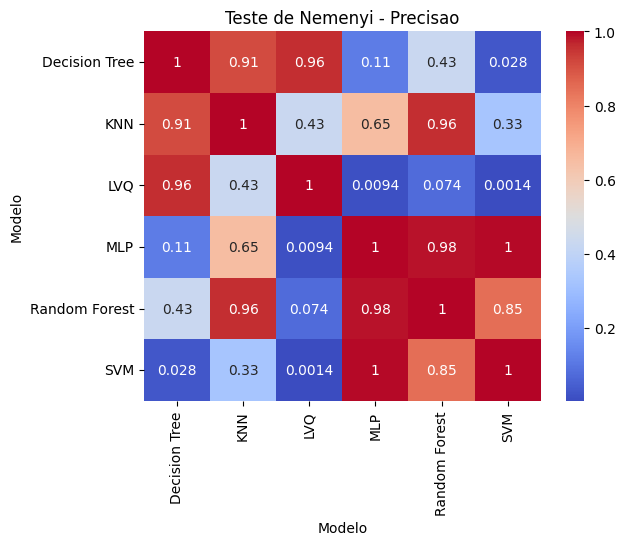


🔎 Teste para: Recall
Friedman χ² = 20.2000, p = 0.0011
➡️ Diferença significativa. Teste de Nemenyi:


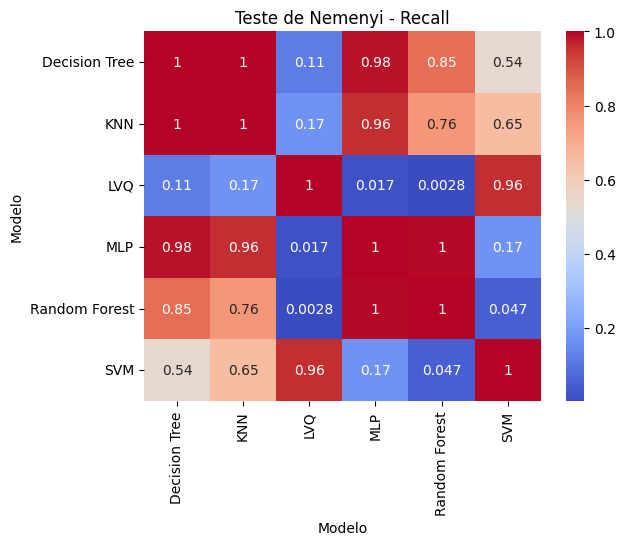


🔎 Teste para: F1
Friedman χ² = 24.3143, p = 0.0002
➡️ Diferença significativa. Teste de Nemenyi:


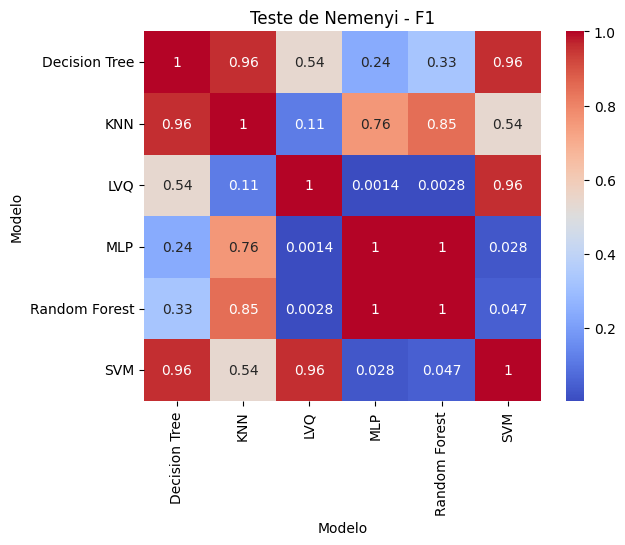


🔎 Teste para: AUC
Friedman χ² = 25.0000, p = 0.0001
➡️ Diferença significativa. Teste de Nemenyi:


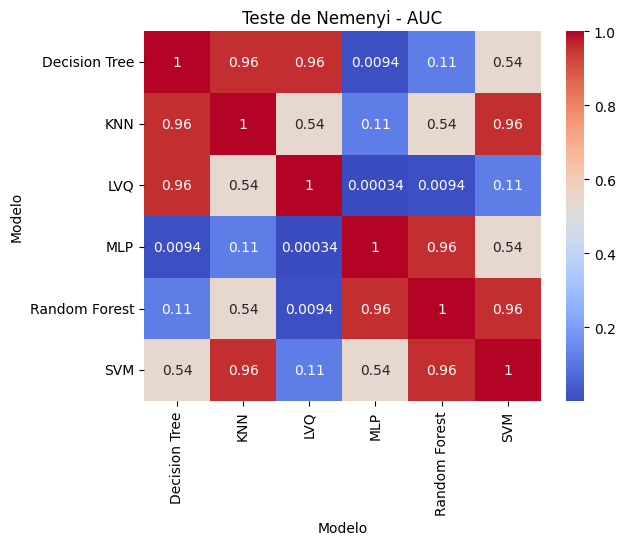

In [65]:
# Verificar diferenças significativas entre os modelos
for metrica in ["Acuracia", "Precisao", "Recall", "F1", "AUC"]:
    print(f"\n🔎 Teste para: {metrica}")
    
    df_m = df_folds.pivot(index='Fold', columns='Modelo', values=metrica)
    
    stat, p = friedmanchisquare(*[df_m[modelo] for modelo in df_m.columns])
    print(f"Friedman χ² = {stat:.4f}, p = {p:.4f}")
    
    if p < 0.05:
        print("➡️ Diferença significativa. Teste de Nemenyi:")
        nemenyi = sp.posthoc_nemenyi_friedman(df_m.values)
        nemenyi.index = df_m.columns
        nemenyi.columns = df_m.columns
        # print(nemenyi)

        sns.heatmap(nemenyi, annot=True, cmap="coolwarm")
        plt.title(f"Teste de Nemenyi - {metrica}")
        plt.show()
    else:
        print("✅ Nenhuma diferença significativa entre os modelos.")


#### 💾 Renomear colunas e salvar resultados por fold em CSV

In [76]:
# Renomear colunas para português
df_folds = df_folds.rename(columns={
    "Modelo": "Classificador",
    "Fold": "Fold",
    "Acuracia": "Acurácia",
    "Precisao": "Precisão",
    "Recall": "Revocação",  # ou mantenha "Recall" se preferir
    "F1": "F1-score",
    "AUC": "AUC-ROC"
})

# Visualizar os dados renomeados
display(df_folds)

# Salvar como CSV
df_folds.to_csv("resultadosPorFold.csv", index=False)


,Classificador,Dobra,Acurácia,Precisão,Revocação,F1-score,AUC-ROC
0,Decision Tree,1,0.783192,0.565718,0.555925,0.560779,0.725584
1,Decision Tree,2,0.783192,0.566438,0.550599,0.558406,0.727751
2,Decision Tree,3,0.785809,0.573747,0.541639,0.557231,0.728521
3,Decision Tree,4,0.780504,0.561246,0.540306,0.550577,0.722972
4,Decision Tree,5,0.787798,0.576657,0.555925,0.566102,0.730177
5,Random Forest,1,0.825460,0.667412,0.595872,0.629617,0.873746
6,Random Forest,2,0.818167,0.649667,0.585220,0.615762,0.869189
7,Random Forest,3,0.833389,0.691654,0.596269,0.640429,0.877624
8,Random Forest,4,0.814987,0.642910,0.576949,0.608146,0.863347
9,Random Forest,5,0.831399,0.684411,0.599201,0.638978,0.882625



📊 Análise de desempenho para: Acurácia

📋 Ranks por Fold:
Classificador  Decision Tree  KNN  LVQ  MLP  Random Forest  SVM
Dobra                                                          
1                        5.0  4.0  6.0  1.0            2.0  3.0
2                        5.0  4.0  6.0  1.0            2.0  3.0
3                        5.0  4.0  6.0  2.0            1.0  3.0
4                        5.0  4.0  6.0  3.0            1.0  2.0
5                        5.0  4.0  6.0  1.0            2.0  3.0

📈 Rank médio por algoritmo:
Classificador
MLP              1.6
Random Forest    1.6
SVM              2.8
KNN              4.0
Decision Tree    5.0
LVQ              6.0
dtype: float64

🔬 Teste de Friedman: χ² = 23.5143, p = 0.0003
➡️ Diferença significativa detectada! Executando teste de Nemenyi...



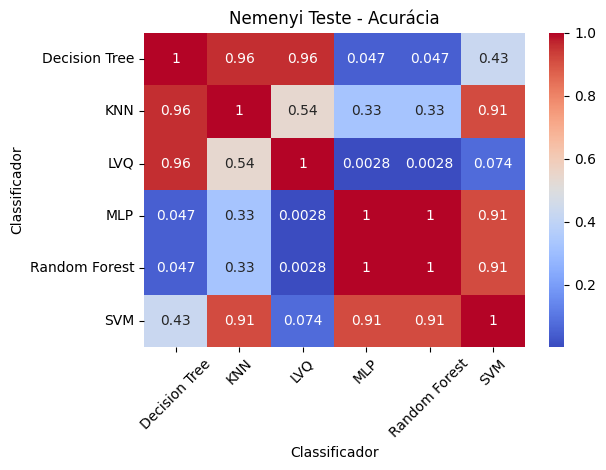


📏 Diferença Crítica (CD): 3.0397


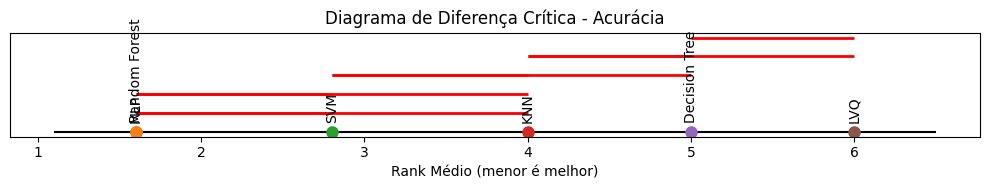


📊 Análise de desempenho para: Precisão

📋 Ranks por Fold:
Classificador  Decision Tree  KNN  LVQ  MLP  Random Forest  SVM
Dobra                                                          
1                        5.0  4.0  6.0  2.0            3.0  1.0
2                        5.0  4.0  6.0  2.0            3.0  1.0
3                        5.0  4.0  6.0  1.0            3.0  2.0
4                        5.0  3.0  6.0  4.0            2.0  1.0
5                        5.0  4.0  6.0  1.0            3.0  2.0

📈 Rank médio por algoritmo:
Classificador
SVM              1.4
MLP              2.0
Random Forest    2.8
KNN              3.8
Decision Tree    5.0
LVQ              6.0
dtype: float64

🔬 Teste de Friedman: χ² = 22.4857, p = 0.0004
➡️ Diferença significativa detectada! Executando teste de Nemenyi...



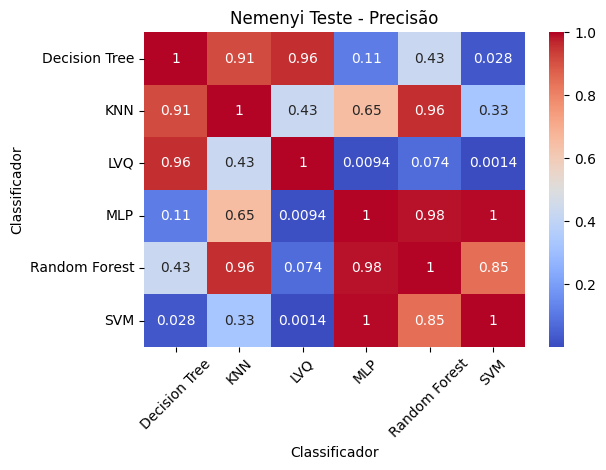


📏 Diferença Crítica (CD): 3.0397


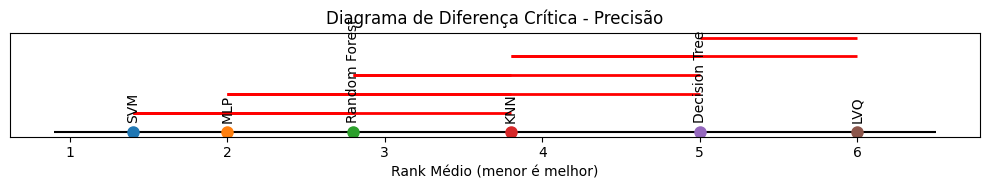


📊 Análise de desempenho para: Revocação

📋 Ranks por Fold:
Classificador  Decision Tree  KNN  LVQ  MLP  Random Forest  SVM
Dobra                                                          
1                        3.0  4.0  6.0  1.0            2.0  5.0
2                        3.0  4.0  6.0  1.0            2.0  5.0
3                        3.0  2.0  6.0  4.0            1.0  5.0
4                        4.0  3.0  6.0  1.0            2.0  5.0
5                        2.0  3.0  6.0  4.0            1.0  5.0

📈 Rank médio por algoritmo:
Classificador
Random Forest    1.6
MLP              2.2
Decision Tree    3.0
KNN              3.2
SVM              5.0
LVQ              6.0
dtype: float64

🔬 Teste de Friedman: χ² = 20.2000, p = 0.0011
➡️ Diferença significativa detectada! Executando teste de Nemenyi...



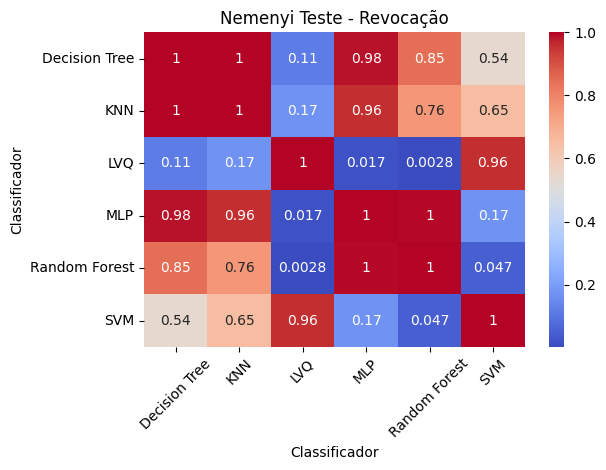


📏 Diferença Crítica (CD): 3.0397


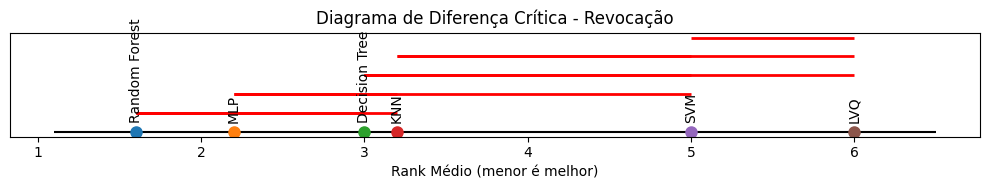


📊 Análise de desempenho para: F1-score

📋 Ranks por Fold:
Classificador  Decision Tree  KNN  LVQ  MLP  Random Forest  SVM
Dobra                                                          
1                        4.0  3.0  6.0  1.0            2.0  5.0
2                        4.0  3.0  6.0  1.0            2.0  5.0
3                        4.0  3.0  6.0  2.0            1.0  5.0
4                        4.0  3.0  6.0  1.0            2.0  5.0
5                        4.0  3.0  6.0  2.0            1.0  5.0

📈 Rank médio por algoritmo:
Classificador
MLP              1.4
Random Forest    1.6
KNN              3.0
Decision Tree    4.0
SVM              5.0
LVQ              6.0
dtype: float64

🔬 Teste de Friedman: χ² = 24.3143, p = 0.0002
➡️ Diferença significativa detectada! Executando teste de Nemenyi...



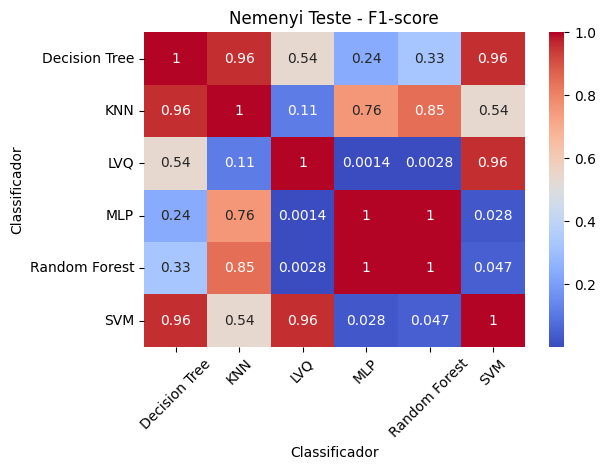


📏 Diferença Crítica (CD): 3.0397


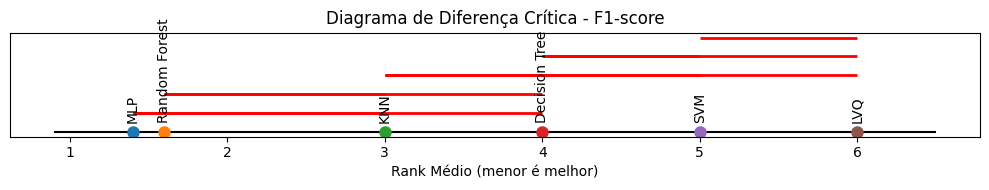


📊 Análise de desempenho para: AUC-ROC

📋 Ranks por Fold:
Classificador  Decision Tree  KNN  LVQ  MLP  Random Forest  SVM
Dobra                                                          
1                        5.0  4.0  6.0  1.0            2.0  3.0
2                        5.0  4.0  6.0  1.0            2.0  3.0
3                        5.0  4.0  6.0  1.0            2.0  3.0
4                        5.0  4.0  6.0  1.0            2.0  3.0
5                        5.0  4.0  6.0  1.0            2.0  3.0

📈 Rank médio por algoritmo:
Classificador
MLP              1.0
Random Forest    2.0
SVM              3.0
KNN              4.0
Decision Tree    5.0
LVQ              6.0
dtype: float64

🔬 Teste de Friedman: χ² = 25.0000, p = 0.0001
➡️ Diferença significativa detectada! Executando teste de Nemenyi...



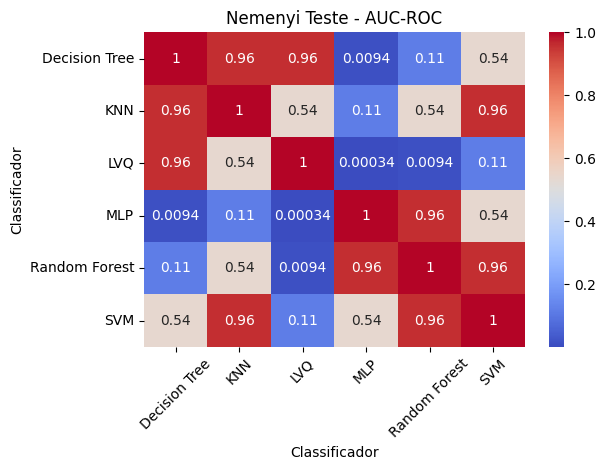


📏 Diferença Crítica (CD): 3.0397


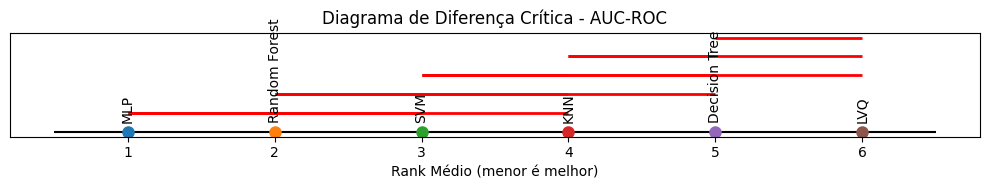

In [81]:
import pandas as pd
import numpy as np
import scikit_posthocs as sp
from scipy.stats import friedmanchisquare
import matplotlib.pyplot as plt
import seaborn as sns

# Para o diagrama de diferença crítica
from math import sqrt
from matplotlib import collections  as mc

# Defina suas métricas
metricas = ["Acurácia", "Precisão", "Revocação", "F1-score", "AUC-ROC"]

# Número de folds
k = df_folds['Dobra'].nunique()

# Número de modelos
modelos = df_folds['Classificador'].unique()
k_modelos = len(modelos)

# Função auxiliar para calcular o Critical Difference (CD)
def critical_difference(k, N, alpha=0.05):
    from scipy.stats import rankdata
    q_alpha = {
        0.10: [0, 1.960, 2.343, 2.569, 2.728],
        0.05: [0, 1.960, 2.343, 2.569, 2.728],
        0.01: [0, 2.343, 2.569, 2.728, 2.850]
    }
    q = 2.569  # valor de q_alpha aproximado para k > 5, alpha=0.05
    return q * sqrt(k * (k + 1) / (6.0 * N))

# Função para plotar o diagrama de diferença crítica
def plot_cd_diagram(avg_ranks, cd, title):
    sorted_models = avg_ranks.sort_values()
    names = sorted_models.index.tolist()
    ranks = sorted_models.values
    
    fig, ax = plt.subplots(figsize=(10, 2))
    ax.set_title(title)
    
    # Linha base
    ax.hlines(1, min(ranks) - 0.5, max(ranks) + 0.5, colors="black")
    
    # Marcação dos modelos
    for i, (model, rank) in enumerate(zip(names, ranks)):
        ax.plot(rank, 1, 'o', markersize=8, label=model)
        ax.text(rank, 1.05, model, rotation=90, ha='center', va='bottom')
    
    # Linhas de CD
    for i in range(len(ranks)):
        for j in range(i + 1, len(ranks)):
            if abs(ranks[i] - ranks[j]) <= cd:
                ax.hlines(1.1 + 0.1 * i, ranks[i], ranks[j], colors="red", linewidth=2)

    ax.set_yticks([])
    ax.set_xlabel("Rank Médio (menor é melhor)")
    plt.tight_layout()
    plt.show()

# Loop principal para cada métrica
for metrica in metricas:
    print(f"\n📊 Análise de desempenho para: {metrica}")
    
    # Pivotar dados
    df_metric = df_folds.pivot(index='Dobra', columns='Classificador', values=metrica)
    
    # Calcular ranks por fold
    ranks = df_metric.rank(axis=1, ascending=False)
    print("\n📋 Ranks por Fold:")
    print(ranks)
    
    # Rank médio
    mean_ranks = ranks.mean().sort_values()
    print("\n📈 Rank médio por algoritmo:")
    print(mean_ranks)
    
    # Teste de Friedman
    stat, p = friedmanchisquare(*[df_metric[modelo] for modelo in df_metric.columns])
    print(f"\n🔬 Teste de Friedman: χ² = {stat:.4f}, p = {p:.4f}")
    
    if p < 0.05:
        print("➡️ Diferença significativa detectada! Executando teste de Nemenyi...\n")
        
        nemenyi = sp.posthoc_nemenyi_friedman(df_metric.values)
        nemenyi.columns = df_metric.columns
        nemenyi.index = df_metric.columns

        # Plot heatmap
        sns.heatmap(nemenyi, annot=True, cmap="coolwarm")
        plt.title(f"Nemenyi Teste - {metrica}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        # CD
        cd = critical_difference(len(mean_ranks), k)
        print(f"\n📏 Diferença Crítica (CD): {cd:.4f}")
        
        # Plot CD Diagram
        plot_cd_diagram(mean_ranks, cd, f"Diagrama de Diferença Crítica - {metrica}")
        
    else:
        print("✅ Nenhuma diferença estatisticamente significativa encontrada.")


## 4. Apresentação dos Resultados

### Fluxograma do Processo de Avaliação

![This is an alt text.](Fluxograma.jpeg)

### Recursos utilizados:

Lista de ferramentas e bibliotecas de código utilizadas na atividade.

Disponível no arquivo `requirements.txt`

#### Ambiente e Utilitários:

* `ipykernel`: Execução do Jupyter Notebook.
* `jupyter_client`: Cliente para comunicação com o servidor Jupyter.
* `jupyter_core`: Núcleo do Jupyter.
* `nest-asyncio`: Permite reutilizar o loop assíncrono dentro de notebooks.
* `prompt_toolkit`: Biblioteca para construção de interfaces interativas de linha de comando.
* `pyzmq`: Comunicação assíncrona entre processos.
* `psutil`: Monitoramento de processos e recursos do sistema.
* `platformdirs`: Localização de diretórios específicos da plataforma.
* `pywin32`: Extensões para Windows.
* `tornado`: Framework assíncrono usado pelo Jupyter Notebook.


#### Processamento de Dados e Análise Estatística:

* `numpy`: Manipulação de arrays numéricos.
* `pandas`: Manipulação e análise de dados tabulares.
* `scikit-learn`: Implementação dos algoritmos de classificação e validação cruzada.
* `scikit-posthocs`: Testes estatísticos pós-hoc (ex.: Nemenyi).
* `scipy`: Testes estatísticos (ex.: Friedman).
* `statsmodels`: Modelagem estatística.


#### Visualização de Dados:

* `matplotlib`: Criação de gráficos.
* `seaborn`: Visualização estatística.
* `colorama`: Exibição de cores no terminal.
* `fonttools`: Manipulação de fontes vetoriais.
* `pillow`: Manipulação de imagens.


#### Código e Depuração:

* `asttokens`: Análise da árvore de sintaxe abstrata (AST).
* `debugpy`: Debugger para Python.
* `executing`: Rastreamento da execução de código.
* `pure_eval`: Avaliação segura de expressões Python.
* `stack-data`: Exibição de pilha de execução.
* `traitlets`: Sistema de configuração e notificação usado pelo Jupyter.


#### Outras Dependências:

* `six`: Compatibilidade entre Python 2 e 3.
* `tzdata`: Suporte a fusos horários.
* `wcwidth`: Cálculo da largura de caracteres em terminais.
* `parso`: Análise sintática usada pelo Jedi.
* `jedi`: Sistema de autocompletar e análise de código.
* `patsy`: Criação de matrizes de design para modelos estatísticos.
* `packaging`: Manipulação de versões e dependências.

## 5. Discussão Crítica e Conclusões (FALTA)

Baseando-se nos resultados, critiquem as limitações e vantagens de cada classificador. Discutam em quais cenários cada classificador seria mais apropriado, usando os resultados obtidos como base para suas argumentações.

##### **Análise dos Resultados para Acurácia:**

Teste de Friedman:

O valor de χ2 =23.5143 com um valor-p de 0.0003 é altamente significativo (α=0.05). Rejeitamos a hipótese nula de que não há diferença significativa no desempenho médio dos algoritmos em termos de Acurácia. Isso indica que os algoritmos apresentam diferenças significativas na proporção de previsões corretas.

Ranks Médios:

O rank médio dos algoritmos para Acurácia é:
- MLP: 1.6
- Random Forest: 1.6
- SVM: 2.8
- KNN: 4.0
- Decision Tree: 5.0
- LVQ: 6.0

O MLP e o Random Forest apresentam os melhores ranks médios de acurácia, seguidos pelo SVM. O LVQ o pior desempenho.
Diagrama de Diferença Crítica (CD) de Nemenyi:

Analisando o diagrama para Acurácia, identificamos os seguintes grupos de algoritmos sem diferenças significativas:
- Grupo 1: MLP e Random Forest (a barra vermelha os conecta)
- Grupo 2: Random Forest e SVM (a barra vermelha os conecta)
- O KNN, Decision Tree e LVQ aparecem mais à direita, sugerindo diferenças significativas em relação aos melhores modelos. O KNN também parece diferente do MLP.

Discussão dos Resultados de Acurácia:

- MLP e Random Forest: O MLP e o Random Forest apresentaram a maior proporção de previsões corretas e não são significativamente diferentes entre si.

- SVM: O SVM teve um desempenho ligeiramente inferior, mas não significativamente diferente do Random Forest.

- KNN: O KNN teve um desempenho pior que o MLP e o Random Forest em termos de acurácia.

- Decision Tree: A Decision Tree apresentou uma acurácia ainda menor.

- LVQ: o LVQ teve o pior desempenho em acurácia.

Relação com o Desbalanceamento:

Dada a distribuição da classe alvo (75% classe 0 e 25% classe 1), um classificador que sempre prevê a classe majoritária (0) teria uma acurácia de 75%. Os resultados de acurácia que você obteve são geralmente mais altos que isso, o que é um bom sinal de que os modelos estão aprendendo algo além de simplesmente prever a classe majoritária.

No entanto, é importante lembrar que uma alta acurácia não garante um bom desempenho na identificação da classe minoritária. Os resultados do F1-score e da AUC são mais informativos nesse aspecto.

##### **Analise dos Resultados para Precisão**

Teste de Friedman:

O valor de χ2 =22.4857 com um valor-p de 0.0004 é altamente significativo (considerando um nível de significância α=0.05). Rejeitamos a hipótese nula de que não há diferença significativa no desempenho médio dos algoritmos em termos de Precisão. Isso indica que pelo menos dois dos seus algoritmos têm um desempenho significativamente diferente nesta métrica.

Ranks Médios:

O rank médio dos algoritmos para Precisão é o seguinte (lembrando que ranks menores são melhores):
- SVM: 1.4
- MLP: 2.0
- Random Forest: 2.8
- KNN: 3.8
- Decision Tree: 5.0
- LVQ: 6.0

O SVM apresenta o melhor rank médio de precisão, seguido pelo MLP e Random Forest. O LVQ teve o pior desempenho médio em precisão.

Diagrama de Diferença Crítica (CD) de Nemenyi:

Observando, podemos identificar os grupos de algoritmos que não apresentam diferenças significativas em precisão:
- Grupo 1: SVM e MLP (a barra vermelha os conecta)
- Grupo 2: MLP, Random Forest e KNN (a barra vermelha os conecta)
- Grupo 3: KNN e Decision Tree (a barra vermelha os conecta)
O LVQ aparece isolado à direita, indicando uma diferença significativa em relação aos demais.

Discussão dos Resultados de Precisão:

SVM e MLP: O SVM e o MLP demonstraram o melhor desempenho em termos de precisão e não apresentaram uma diferença estatisticamente significativa entre si. Isso sugere que ambos os modelos são eficazes em minimizar falsos positivos, ou seja, quando predizem a classe positiva (1), eles tendem a estar corretos. Em um cenário desbalanceado onde a classe positiva é minoritária, alta precisão pode ser valiosa se o custo de uma previsão positiva incorreta for alto.

Random Forest e KNN: Estes algoritmos tiveram um desempenho intermediário em precisão. O Random Forest não apresentou diferença significativa em relação ao MLP e ao KNN, enquanto o KNN não se diferenciou significativamente do MLP e do Decision Tree.

Decision Tree: A Decision Tree apresentou um rank médio mais baixo em precisão, indicando um desempenho inferior em comparação com os melhores modelos.

LVQ: O LVQ teve o pior desempenho em precisão, com uma diferença estatisticamente significativa em relação a todos os outros algoritmos. Isso sugere que o LVQ tende a gerar mais falsos positivos em suas previsões da classe minoritária.

Implicações para o Problema Desbalanceado:

A alta precisão observada no SVM e MLP pode ser um bom sinal, indicando que quando eles preveem a classe minoritária (1), eles geralmente estão certos. No entanto, é crucial analisar o Recall desses modelos para entender se eles estão identificando uma proporção razoável dos verdadeiros positivos. Um modelo com alta precisão, mas baixo recall, pode ser conservador ao prever a classe minoritária, perdendo muitos casos importantes.

O baixo desempenho do LVQ em precisão pode ser problemático, pois ele tende a gerar mais alarmes falsos para a classe minoritária.

##### **Analise dos Resultados para Recall**

Teste de Friedman:

O valor de χ2 =20.2000 com um valor-p de 0.0011 também é estatisticamente significativo (α=0.05). Rejeitamos a hipótese nula de que não há diferença significativa no desempenho médio dos algoritmos em termos de Revocação. Isso indica que pelo menos dois dos seus algoritmos têm um desempenho significativamente diferente na capacidade de identificar a classe positiva.
Ranks Médios:

O rank médio dos algoritmos para Revocação é:
- Random Forest: 1.6
- MLP: 2.2
- Decision Tree: 3.0
- KNN: 3.2
- SVM: 5.0
- LVQ: 6.0

O Random Forest apresenta o melhor rank médio de revocação, seguido de perto pelo MLP. O SVM e o LVQ tiveram os piores desempenhos médios em termos de identificar a classe positiva.
Diagrama de Diferença Crítica (CD) de Nemenyi:

Analisando, para Revocação, identificamos os seguintes grupos de algoritmos sem diferenças significativas:
- Grupo 1: Random Forest e MLP (a barra vermelha os conecta)
- Grupo 2: MLP, Decision Tree e KNN (a barra vermelha os conecta)
- O SVM e o LVQ aparecem isolados à direita, sugerindo diferenças significativas em relação aos melhores modelos. O SVM também parece diferente do Random Forest e do MLP.
Discussão dos Resultados de Revocação:

Random Forest e MLP: O Random Forest e o MLP demonstraram a melhor capacidade de recuperar instâncias da classe positiva (classe minoritária) e não apresentaram uma diferença estatisticamente significativa entre si. Em um problema desbalanceado, um alto recall é crucial para garantir que a maioria dos casos da classe de interesse seja identificada.

Decision Tree e KNN: Estes algoritmos tiveram um desempenho intermediário em termos de recall. Eles não apresentaram diferenças significativas em relação ao MLP e entre si.

SVM: O SVM apresentou um rank médio mais baixo em revocação, indicando que ele é menos eficaz em identificar todos os casos positivos em comparação com o Random Forest e o MLP. Houve uma diferença significativa entre o SVM e os dois melhores algoritmos.

LVQ: Similar ao que observamos na Precisão, o LVQ também teve o pior desempenho em Revocação, com uma diferença significativa em relação a todos os outros algoritmos. Isso sugere que o LVQ falha em identificar uma proporção considerável da classe positiva.

Comparação com os Resultados de Precisão:

Trade-off: Podemos começar a observar possíveis trade-offs entre Precisão e Revocação para alguns algoritmos. Por exemplo, o SVM e o MLP tiveram alta Precisão, mas o SVM mostrou um desempenho inferior em Revocação em comparação com o Random Forest e o MLP (embora a diferença entre os dois últimos não seja significativa para Recall).

LVQ Consistência: O LVQ consistentemente apresentou o pior desempenho tanto em Precisão quanto em Revocação, sugerindo que este algoritmo pode não ser adequado para este problema específico com os dados atuais.

##### **Análise dos Resultados para F1-Score**

Teste de Friedman:

O valor de χ2 =24.3143 com um valor-p de 0.0002 é altamente significativo (α=0.05). Rejeitamos a hipótese nula de que não há diferença significativa no desempenho médio dos algoritmos em termos de F1-score. Isso indica que há diferenças significativas no equilíbrio entre Precisão e Revocação alcançado pelos diferentes modelos.
Ranks Médios:

O rank médio dos algoritmos para F1-score é:
- MLP: 1.4
- Random Forest: 1.6
- KNN: 3.0
- Decision Tree: 4.0
- SVM: 5.0
- LVQ: 6.0
O MLP e o Random Forest apresentam os melhores ranks médios de F1-score, indicando um bom equilíbrio entre Precisão e Revocação. O LVQ continua com o pior desempenho.
Diagrama de Diferença Crítica (CD) de Nemenyi:

Analisando para F1-score, identificamos os seguintes grupos de algoritmos sem diferenças significativas:
- Grupo 1: MLP e Random Forest (a barra vermelha os conecta)
- Grupo 2: Random Forest e KNN (a barra vermelha os conecta)
- Grupo 3: KNN e Decision Tree (a barra vermelha os conecta)
O SVM e o LVQ aparecem isolados à direita, sugerindo diferenças significativas em relação aos melhores modelos. O SVM também parece diferente do MLP e do Random Forest.
Discussão dos Resultados de F1-score:

MLP e Random Forest: O MLP e o Random Forest alcançaram o melhor equilíbrio entre Precisão e Revocação, sem apresentar diferenças significativas entre si. Isso sugere que esses modelos são os mais eficazes em lidar com o desbalanceamento da classe, oferecendo um bom compromisso entre minimizar falsos positivos e maximizar a identificação de verdadeiros positivos.

KNN: O KNN teve um desempenho intermediário em F1-score, não sendo significativamente diferente do Random Forest e da Decision Tree.

Decision Tree: A Decision Tree apresentou um desempenho inferior em comparação com o MLP e o Random Forest no que diz respeito ao F1-score.

SVM: O SVM, apesar de ter apresentado boa Precisão, teve um F1-score menor devido ao seu desempenho inferior em Revocação. Isso demonstra a importância de considerar o F1-score em problemas desbalanceados, pois ele penaliza modelos com um desequilíbrio acentuado entre Precisão e Revocação.

LVQ: O LVQ continua a apresentar o pior desempenho em F1-score, consistente com seus resultados ruins em Precisão e Revocação.

Implicações para o Problema Desbalanceado:

Os resultados do F1-score reforçam a ideia de que o MLP e o Random Forest são os candidatos mais promissores para este problema, pois conseguem manter um bom equilíbrio entre a qualidade das previsões positivas e a capacidade de identificar todos os casos positivos da classe minoritária.

O desempenho inferior do SVM em F1-score, apesar da boa precisão, destaca a necessidade de um bom recall para obter um bom desempenho geral em problemas desbalanceados.

##### **Análise dos resultados para AUC-ROC**

Teste de Friedman:

O valor de χ2 =25.0000 com um valor-p de 0.0001 é altamente significativo (α=0.05).Rejeitamos a hipótese nula de que não há diferença significativa no desempenho médio dos algoritmos em termos de AUC-ROC. Isso indica que os algoritmos têm capacidades de discriminação significativamente diferentes.
Ranks Médios:

O rank médio dos algoritmos para AUC-ROC é:
- MLP: 1.0
- Random Forest: 2.0
- SVM: 3.0
- KNN: 4.0
- Decision Tree: 5.0
- LVQ: 6.0
O MLP apresenta o melhor rank médio de AUC, seguido pelo Random Forest e SVM. O LVQ continua com o pior desempenho.
Diagrama de Diferença Crítica (CD) de Nemenyi:

Analisando para AUC-ROC, identificamos os seguintes grupos de algoritmos sem diferenças significativas:
- Grupo 1: MLP e Random Forest (a barra vermelha os conecta)
- Grupo 2: Random Forest e SVM (a barra vermelha os conecta)
- Grupo 3: SVM e KNN (a barra vermelha os conecta)
- Grupo 4: KNN e Decision Tree (a barra vermelha os conecta)
O LVQ aparece isolado à direita, sugerindo diferenças significativas em relação a todos os outros.
Discussão dos Resultados de AUC-ROC:

MLP e Random Forest: O MLP e o Random Forest demonstraram a melhor capacidade de discriminação entre as classes, sem apresentar uma diferença estatisticamente significativa entre si. Isso sugere que esses modelos são os mais eficazes em ordenar corretamente as instâncias de acordo com a probabilidade de pertencerem à classe positiva.

SVM: O SVM teve um desempenho ligeiramente inferior, mas não significativamente diferente do Random Forest. Ele ainda demonstra uma boa capacidade de discriminação.

KNN: O KNN apresentou um desempenho intermediário em termos de AUC, sendo significativamente diferente do MLP e do Random Forest, mas não do SVM e da Decision Tree.

Decision Tree: A Decision Tree mostrou uma capacidade de discriminação inferior em comparação com os três melhores modelos.

LVQ: Mais uma vez, o LVQ teve o pior desempenho, indicando uma baixa capacidade de distinguir entre as classes.

Consistência com Resultados Anteriores:

Os resultados da AUC reforçam a superioridade do MLP e do Random Forest, que também se destacaram no F1-score e tiveram bom desempenho em Precisão e Revocação.

O desempenho consistente do LVQ como o pior em todas as métricas sugere que ele pode não ser uma boa escolha para este problema específico.

O SVM, que teve a melhor Precisão, mostra uma boa capacidade de discriminação (AUC), mas um Recall inferior, o que resultou em um F1-score mais baixo em comparação com o MLP e o Random Forest.

##### ***Conclusão Geral***

Após analisar os resultados para todas as cinco métricas, podemos tirar algumas conclusões importantes:

- Desempenho Consistente: O MLP e o Random Forest se destacaram de forma consistente em várias métricas importantes para o seu problema desbalanceado, incluindo F1-score e AUC. Eles também apresentaram boa acurácia, precisão e recall (embora o Random Forest tenha tido um recall ligeiramente melhor). Esses dois algoritmos parecem ser os mais promissores para a tarefa.

- Bom Desempenho em Precisão: O SVM demonstrou a melhor precisão, o que significa que quando ele prevê a classe positiva, ele tende a estar correto. No entanto, seu recall foi inferior ao do MLP e do Random Forest, resultando em um F1-score mais baixo. Dependendo do custo de falsos positivos versus falsos negativos, o SVM ainda pode ser considerado.

- Desempenho Intermediário: O KNN geralmente teve um desempenho intermediário em todas as métricas.

- Desempenho Inferior: A Decision Tree consistentemente ficou entre os piores desempenhos.

- Desempenho Ruim: O LVQ apresentou o pior desempenho em todas as métricas avaliadas, sugerindo que ele provavelmente não é adequado para este problema com os dados atuais.

- MLP e Random Forest: Dada a sua performance robusta em F1-score e AUC,  aprofundar a análise nesse dois algoritmos. Isso pode envolver ajuste de hiperparâmetros, análise de importância de features (para o Random Forest), etc.

- Considerar o SVM: Se a alta precisão for crucial , levando em consideração de que ele pode perder mais casos positivos.

- Investigar o KNN: O KNN pode ser considerado como uma alternativa se a interpretabilidade for importante, mas seu desempenho geral foi inferior aos dois melhores modelos.

- Descartar o LVQ: Com base nos resultados consistentes de baixo desempenho, o LVQ provavelmente não é uma boa escolha.
